# TCRAFT Paired-Chain oPool Library Design

Design one combinatorial oPool per peptide where **alpha and beta CDR3 sequences are encoded on a single oligo** (TCRAFT cloning strategy).

## Why this differs from the splitchain design

| | Splitchain | TCRAFT paired |
|-|------------|---------------|
| Alpha + beta | Separate oligos, randomly shuffled | Same oligo, explicitly linked |
| Diversity formula | alpha_div × beta_div (cross-product) | Σ unique_diversity per oligo (additive) |
| Epistasis exploitation | None — chains co-occur only by chance | Direct: synergistic positions share an oligo |
| Library size needed | ~√target per chain | Full target per peptide |

## Design philosophy

Positions and amino acids are selected in two stages:

1. **Candidate scoring** — each `(position, AA)` on each chain is scored by its mean single-mutant enrichment (log2fc) z-scored across peptides.  Epistasis is deliberately excluded here to avoid double-counting.

2. **Backbone selection** — an **exhaustive search** over all valid subsets of candidate positions finds the combination that maximises:
   - total single-effect quality of included positions, **plus**
   - total pairwise cross-chain epistasis across all position pairs in the backbone (positive epistasis rewarded, negative penalised asymmetrically with `NEG_EPI_WEIGHT > EPI_WEIGHT`)

   The search is subject to a combinatorial diversity budget (`TIER1_FRAC × TARGET_DIVERSITY`).

## Oligo tiers

| Tier | Description |
|------|-------------|
| `tier1_backbone` | Globally optimal set of positions from both chains co-varied on every oligo; diversity = product of encoded AAs across all tier1 positions |
| `tier2_ext` | One oligo per extension: backbone + one additional position from either chain; ranked by single-effect score |
| `tier3` | Positions that could not fit the diversity budget; remain at WT |

**Adapters** are not included — add externally once the TCRAFT cloning strategy is finalised.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
from itertools import product, combinations
import warnings
warnings.filterwarnings('ignore')

NB_DIR   = Path('/cluster/project/reddy/marluca/NGS_pipeline/notebooks')
DATA_DIR = Path('/cluster/project/reddy/marluca/NGS_pipeline/data/P3620_LUCA-TCRDMF5-abDMS/04_variant_labeling')
OUT_DIR  = Path('/cluster/home/sschulz/NGS_pipeline/notebooks/opool_designs_tcraft')
OUT_DIR.mkdir(exist_ok=True)
print(f'Output: {OUT_DIR}')

Output: /cluster/home/sschulz/NGS_pipeline/notebooks/opool_designs_tcraft


In [57]:
PEPTIDES = ['DRG01','DRG04','GIG01','GIG02','GIG03','GIG04','GIG05']

WT_ALPHA  = 'AVNFGGGKLI'
WT_BETA   = 'ASSLSFGTEAF'
ALPHA_LEN = len(WT_ALPHA)
BETA_LEN  = len(WT_BETA)

ENRICHMENT_COL = {p: 'enrich_pos1x_vs_neg' for p in PEPTIDES}
ENRICHMENT_COL['GIG02'] = 'enrich_pos2x_vs_neg'
PSEUDOCOUNT = 1e-3

# ── Design parameters ────────────────────────────────────────────────────
TARGET_DIVERSITY  = 10_000_000   # total unique paired sequences per peptide (soft goal)
MAX_DIVERSITY     = 15_000_000   # hard ceiling per peptide
MIN_SCORE         = 0.1    # min composite score — lowered to include weakly enriched positions
K_MAX             = 8     # max candidate AAs pulled per position (pre-filter)
EPI_WEIGHT        = 3.0   # reward for positive epistasis (pair ranking + composite)
NEG_EPI_WEIGHT    = 6.0   # penalty for negative epistasis (pair ranking + composite)
CODON_EPI_WEIGHT  = 0.3   # light tiebreaker in IUPAC codon selection
EPI_MIN_OBS       = 7     # observations below this are confidence-discounted
TIER1_FRAC        = 0.33   # backbone diversity cap as fraction of per-peptide target

STOP_PENALTY      = 10.0
EFFICIENCY_THRESH = 0.3

# Positions permanently excluded from Tier 1 (N-terminal positions)
TIER1_EXCLUDE = {
    'alpha': {0},
    'beta':  {0, 1},
}

TOP_K = 2
# Number of top-ranked enriched AAs (beyond WT) that MUST be encoded at each position.
#   TOP_K = 0  → only WT is a hard constraint (very narrow codons, low diversity)
#   TOP_K = 1  → WT + top enriched AA
#   TOP_K = 2  → WT + top 2 enriched AAs; IUPAC degeneracy naturally encodes ~6-10 AAs
#               per position, multiplying backbone diversity substantially

print(f'Alpha WT: {WT_ALPHA}  ({ALPHA_LEN} aa)')
print(f'Beta  WT: {WT_BETA}  ({BETA_LEN} aa)')
print(f'{len(PEPTIDES)} peptides: {PEPTIDES}')
print(f'Diversity target: {TARGET_DIVERSITY:,}  (hard cap: {MAX_DIVERSITY:,})')
print(f'Tier1 backbone cap: {TIER1_FRAC:.0%} of per-peptide target')
print(f'Tier1 excluded positions: alpha={sorted(TIER1_EXCLUDE.get("alpha", []))}  beta={sorted(TIER1_EXCLUDE.get("beta", []))}')
print(f'TOP_K={TOP_K}  MIN_SCORE={MIN_SCORE}  K_MAX={K_MAX}')
print(f'EPI_WEIGHT={EPI_WEIGHT}  NEG_EPI_WEIGHT={NEG_EPI_WEIGHT}')


Alpha WT: AVNFGGGKLI  (10 aa)
Beta  WT: ASSLSFGTEAF  (11 aa)
7 peptides: ['DRG01', 'DRG04', 'GIG01', 'GIG02', 'GIG03', 'GIG04', 'GIG05']
Diversity target: 10,000,000  (hard cap: 15,000,000)
Tier1 backbone cap: 33% of per-peptide target
Tier1 excluded positions: alpha=[0]  beta=[0, 1]
TOP_K=2  MIN_SCORE=0.1  K_MAX=8
EPI_WEIGHT=3.0  NEG_EPI_WEIGHT=6.0


## Genetic Code and IUPAC Utilities

Builds `IUPAC_PROPS`: a lookup table of all valid IUPAC degenerate triplets mapping each triplet to the set of amino acids it encodes and the fraction of codons that produce stop codons.

This is used in `_canonical_codon` to select the best degenerate codon for each variable position — one that covers the required amino acids (WT + top enriched AAs) while maximising mean composite score and minimising stop-codon leakage.


In [49]:
GENETIC_CODE = {
    'ATA':'I','ATC':'I','ATT':'I','ATG':'M',
    'ACA':'T','ACC':'T','ACG':'T','ACT':'T',
    'AAC':'N','AAT':'N','AAA':'K','AAG':'K',
    'AGC':'S','AGT':'S','AGA':'R','AGG':'R',
    'CTA':'L','CTC':'L','CTG':'L','CTT':'L',
    'CCA':'P','CCC':'P','CCG':'P','CCT':'P',
    'CAC':'H','CAT':'H','CAA':'Q','CAG':'Q',
    'CGA':'R','CGC':'R','CGG':'R','CGT':'R',
    'GTA':'V','GTC':'V','GTG':'V','GTT':'V',
    'GCA':'A','GCC':'A','GCG':'A','GCT':'A',
    'GAC':'D','GAT':'D','GAA':'E','GAG':'E',
    'GGA':'G','GGC':'G','GGG':'G','GGT':'G',
    'TCA':'S','TCC':'S','TCG':'S','TCT':'S',
    'TTC':'F','TTT':'F','TTA':'L','TTG':'L',
    'TAC':'Y','TAT':'Y','TAA':'*','TAG':'*',
    'TGC':'C','TGT':'C','TGA':'*','TGG':'W',
}
IUPAC_BASES = {
    'A':{'A'},'C':{'C'},'G':{'G'},'T':{'T'},
    'R':{'A','G'},'Y':{'C','T'},'S':{'G','C'},'W':{'A','T'},
    'K':{'G','T'},'M':{'A','C'},
    'B':{'C','G','T'},'D':{'A','G','T'},'H':{'A','C','T'},'V':{'A','C','G'},
    'N':{'A','C','G','T'},
}

def decode_iupac(triplet):
    codons = [b1+b2+b3 for b1 in IUPAC_BASES[triplet[0]]
                        for b2 in IUPAC_BASES[triplet[1]]
                        for b3 in IUPAC_BASES[triplet[2]]]
    aas, stops = set(), 0
    for c in codons:
        aa = GENETIC_CODE.get(c,'?')
        if aa == '*': stops += 1
        else: aas.add(aa)
    return aas, stops/len(codons)

ALL_IUPAC = list(IUPAC_BASES.keys())
IUPAC_PROPS = {}
for _t in product(ALL_IUPAC, repeat=3):
    _triplet = ''.join(_t)
    _aas, _sf = decode_iupac(_triplet)
    if _aas:
        IUPAC_PROPS[_triplet] = {'aas': frozenset(_aas), 'stop_frac': _sf}

print(f'Pre-computed {len(IUPAC_PROPS)} valid IUPAC triplets')

Pre-computed 3370 valid IUPAC triplets


## Load Enrichment Data

Loads `SINGLE_FX`: per-peptide single-mutant effects.  For each variant with exactly one mutation on either the alpha or beta chain, the deviation from the population mean log2 enrichment is recorded as `log2fc` for that `(chain, position, AA)`.

Used downstream in `pool_composite_scores` to rank candidate amino acids at each position.


In [50]:
def load_single_effects(pep_list):
    result = {}
    for pep in pep_list:
        df  = pd.read_csv(DATA_DIR / f'{pep}.variant_labeling.csv')
        col = ENRICHMENT_COL[pep]
        if col not in df.columns: col = 'enrich_pos1x_vs_neg'
        df['log2e']     = np.log2(df[col].clip(lower=PSEUDOCOUNT))
        baseline        = df['log2e'].mean()
        df['log2e_dev'] = df['log2e'] - baseline
        rows = []
        for _, r in df.iterrows():
            v = r['log2e_dev']
            aseq, bseq = r['alpha_aa'], r['beta_aa']
            if aseq != WT_ALPHA:
                for pos in range(ALPHA_LEN):
                    if aseq[pos] != WT_ALPHA[pos]:
                        rows.append(('alpha', pos, aseq[pos], v)); break
            if bseq != WT_BETA:
                for pos in range(BETA_LEN):
                    if bseq[pos] != WT_BETA[pos]:
                        rows.append(('beta', pos, bseq[pos], v)); break
        fx = (pd.DataFrame(rows, columns=['chain','position','aa','log2e_dev'])
              .groupby(['chain','position','aa'])['log2e_dev']
              .agg(log2fc='mean', n_variants='count').reset_index())
        result[pep] = fx
    return result

print('Loading single effects...')
try:
    print(f'Done. DRG01: {len(SINGLE_FX["DRG01"])} entries')
except Exception as e:
    print(f'Error loading DRG01: {e}')
    SINGLE_FX = load_single_effects(PEPTIDES)
    print(f'Done. DRG01: {len(SINGLE_FX["DRG01"])} entries')

SINGLE_FX['DRG01'].head(6)

Loading single effects...
Done. DRG01: 399 entries


,chain,position,aa,log2fc,n_variants
0,alpha,0,C,0.117227,100
1,alpha,0,D,0.072407,73
2,alpha,0,E,-0.145926,106
3,alpha,0,F,0.188084,123
4,alpha,0,G,3.041486,175
5,alpha,0,H,0.565789,87


## Compute Epistasis

Loads `EPISTASIS`: for each double-mutant variant (one alpha mutation + one beta mutation), epistasis is defined as the **deviation from additive single effects**:

```
epistasis = observed_log2fc − (single_effect_alpha + single_effect_beta)
```

- **Positive epistasis** → the pair cooperates better than expected (synergy)
- **Negative epistasis** → the pair cooperates worse than expected (antagonism)

This is the signal used in the backbone search to prefer position combinations whose encoded amino acids synergise across chains.


In [51]:
def compute_epistasis(pep_list):
    result = {}
    for pep in pep_list:
        df  = pd.read_csv(DATA_DIR / f'{pep}.variant_labeling.csv')
        col = ENRICHMENT_COL[pep]
        if col not in df.columns: col = 'enrich_pos1x_vs_neg'
        df['log2e']     = np.log2(df[col].clip(lower=PSEUDOCOUNT))
        baseline        = df['log2e'].mean()
        df['log2e_dev'] = df['log2e'] - baseline
        fx = SINGLE_FX[pep].set_index(['chain','position','aa'])['log2fc'].to_dict()
        rows = []
        for _, r in df.iterrows():
            aseq, bseq = r['alpha_aa'], r['beta_aa']
            if aseq == WT_ALPHA or bseq == WT_BETA: continue
            apos = aaa = bpos = baa = None
            for pos in range(ALPHA_LEN):
                if aseq[pos] != WT_ALPHA[pos]: apos, aaa = pos, aseq[pos]; break
            for pos in range(BETA_LEN):
                if bseq[pos] != WT_BETA[pos]: bpos, baa = pos, bseq[pos]; break
            if apos is None or bpos is None: continue
            ma = fx.get(('alpha', apos, aaa), 0.0)
            mb = fx.get(('beta',  bpos, baa), 0.0)
            obs = r['log2e_dev']
            rows.append({'alpha_pos': apos, 'aa_alpha': aaa,
                         'beta_pos':  bpos, 'aa_beta':  baa,
                         'log2fc_obs': obs, 'log2fc_exp': ma+mb,
                         'epistasis': obs - (ma+mb)})
        result[pep] = pd.DataFrame(rows)
    return result

try:
    print('Loading epistasis...')
    print(f'Done. DRG01: {len(EPISTASIS["DRG01"])} pairs')
except Exception as e:
    print(f'Error loading DRG01 epistasis: {e}')
    print('Computing epistasis...')
    EPISTASIS = compute_epistasis(PEPTIDES)
    print(f'Done. DRG01: {len(EPISTASIS["DRG01"])} pairs')
EPISTASIS['DRG01'].head(6)

Loading epistasis...
Done. DRG01: 30317 pairs


,alpha_pos,aa_alpha,beta_pos,aa_beta,log2fc_obs,log2fc_exp,epistasis
0,1,A,1,A,2.289790,2.896811,-0.607021
1,1,C,1,A,4.988507,1.362625,3.625882
2,1,E,1,A,-2.625310,-0.788783,-1.836527
3,1,F,1,A,-2.625310,-0.435898,-2.189412
4,1,G,1,A,-4.270127,-0.198898,-4.071229
5,1,H,1,A,-3.451897,-0.658752,-2.793145


## Candidate Scoring

`pool_composite_scores` computes a **single-effect composite score** for every `(position, AA)` on one chain:

```
composite = z-score( mean log2fc across peptides )
```

Epistasis is intentionally excluded at this stage — it is applied exclusively in the backbone search (cell 12) where all pairwise cross-chain interactions are scored simultaneously.  This avoids double-counting and keeps candidate filtering (via `MIN_SCORE`) purely signal-based on single-mutant fitness.

**`MIN_SCORE`** controls how many positions enter the search: lower values include weakly enriched positions and increase potential diversity; higher values restrict to confidently enriched positions only.


In [58]:
def pool_composite_scores(pep_list, chain):
    """Per-position, per-AA score based purely on single-mutant enrichment (log2fc).
    Epistasis is handled exclusively at the pair level in compute_joint_pair_scores."""
    chain_dfs = [SINGLE_FX[p][SINGLE_FX[p]['chain']==chain] for p in pep_list if p in SINGLE_FX]
    pooled = (pd.concat(chain_dfs, ignore_index=True)
              .groupby(['position','aa'])['log2fc'].mean().reset_index()
              .rename(columns={'log2fc':'base_score'}))
    pooled['composite'] = (pooled['base_score'] - pooled['base_score'].mean()) / pooled['base_score'].std()
    return pooled.sort_values(['position','composite'], ascending=[True,False])


print(f'{PEPTIDES[0]} alpha composite scores (top 8):')
print(pool_composite_scores([PEPTIDES[0]],'alpha').nlargest(8,'composite').to_string(index=False))
print(f'\n{PEPTIDES[0]} beta composite scores (top 8):')
print(pool_composite_scores([PEPTIDES[0]],'beta').nlargest(8,'composite').to_string(index=False))


DRG01 alpha composite scores (top 8):
 position aa  base_score  composite
        1  A    3.553340   3.713047
        9  L    3.180584   3.324303
        0  G    3.041486   3.179239
        7  V    2.968999   3.103643
        3  M    2.959117   3.093337
        7  L    2.797201   2.924476
        7  M    2.498668   2.613139
        3  Q    2.453896   2.566447

DRG01 beta composite scores (top 8):
 position aa  base_score  composite
        4  V    4.702643   4.688997
        4  L    4.056235   4.045446
        7  R    3.436143   3.428095
        4  I    3.034241   3.027970
        8  K    2.870355   2.864809
        7  K    2.841278   2.835860
        8  I    2.669586   2.664927
        8  M    2.423168   2.419598


## Paired oPool Design

Each oligo encodes the full alpha CDR3 + full beta CDR3 as a single sequence (63 nt, adapters added later).

### Step 1 — Candidate preparation

For each chain, positions with `composite >= MIN_SCORE` are retained.  For each qualifying position an IUPAC degenerate codon is selected that must encode `{WT, top-1, top-2, ...}` enriched AAs (`TOP_K` controls how many top AAs are required).  IUPAC degeneracy naturally encodes additional AAs beyond the required set; a light epistasis tiebreaker (`CODON_EPI_WEIGHT`) prefers codons whose bonus AAs do not have known negative cross-chain interactions.

### Step 2 — Exhaustive backbone search (Tier 1)

All valid subsets of candidate alpha positions × all valid subsets of candidate beta positions are evaluated.  For each combination the score is:

```
score = Σ pos_quality(p)           ← mean composite score of encoded AAs
      + Σ pair_epi(apos, bpos)     ← for every alpha-beta position pair in the backbone
```

`pair_epi` uses asymmetric epistasis weighting: positive epistasis is rewarded with `EPI_WEIGHT`, negative epistasis is penalised with `NEG_EPI_WEIGHT` (2× stronger).  The combination with the highest score that fits within `TIER1_FRAC × TARGET_DIVERSITY` is selected as the backbone.  This is the **globally optimal** backbone within the candidate set.

Typical search size: ~5–10 candidate positions per chain → ≤ 100k combinations, sub-second.

### Step 3 — Extension oligos (Tier 2)

Positions not in the backbone are added one at a time (by best single-effect score) as individual extension oligos, each containing the full backbone plus the one new position.  Extensions add diversity additively up to `TARGET_DIVERSITY`.

### What controls what

| Goal | Parameters to change |
|------|----------------------|
| More diversity | ↑ `TOP_K`, ↓ `MIN_SCORE`, ↑ `TIER1_FRAC` |
| Stricter epistasis quality | ↑ `NEG_EPI_WEIGHT` relative to `EPI_WEIGHT` |
| Broader/narrower codons | ↑/↓ `TOP_K`, adjust `CODON_EPI_WEIGHT` |


In [60]:
from itertools import combinations

# All design parameters (EPI_WEIGHT, NEG_EPI_WEIGHT, CODON_EPI_WEIGHT, EPI_MIN_OBS,
# TOP_K, MIN_SCORE, TIER1_FRAC, ...) are defined in the config cell (cell 2).
#
# Pipeline overview:
#   pool_composite_scores()         → z-scored single-effect score per (pos, AA)
#   _build_epi_lookup()             → (apos, aaa, bpos, baa) → (mean_epistasis, n_obs)
#   _canonical_codon()              → best IUPAC triplet covering {WT + top-K AAs}
#   _precompute_backbone_scores()   → fast lookup tables for exhaustive search
#   exhaustive_backbone_search()    → globally optimal backbone within diversity budget
#   design_paired_pool()            → orchestrates above; builds Tier1 + Tier2 oligos

def _wt_triplets(wt_seq):
    t = {}
    for pos, aa in enumerate(wt_seq):
        for codon, enc_aa in GENETIC_CODE.items():
            if enc_aa == aa: t[pos] = codon; break
    return t


def _build_epi_lookup(pep):
    """(apos, aaa, bpos, baa) -> (mean_epistasis, n_obs) for one peptide."""
    epi_df = EPISTASIS.get(pep)
    epi_lookup = {}
    if epi_df is not None and not epi_df.empty:
        epi_agg = (epi_df
                   .groupby(['alpha_pos', 'aa_alpha', 'beta_pos', 'aa_beta'])['epistasis']
                   .agg(mean_epi='mean', n='count')
                   .reset_index())
        for _, r in epi_agg.iterrows():
            epi_lookup[(int(r['alpha_pos']), r['aa_alpha'],
                        int(r['beta_pos']),  r['aa_beta'])] = (r['mean_epi'], int(r['n']))
    return epi_lookup


def _codon_epi_penalty(chain, pos, encoded_aas, cands_by_key, epi_lookup):
    penalty = 0.0
    for aa in encoded_aas:
        for (other_chain, other_pos), other_cands in cands_by_key.items():
            if other_chain == chain:
                continue
            for other_aa in [c[0] for c in other_cands]:
                if chain == 'alpha':
                    epi, n = epi_lookup.get((pos, aa, other_pos, other_aa), (0.0, 0))
                else:
                    epi, n = epi_lookup.get((other_pos, other_aa, pos, aa), (0.0, 0))
                if n > 0 and epi < 0:
                    penalty += epi * min(1.0, n / EPI_MIN_OBS)
    return penalty


def _canonical_codon(pos, cands_by_pos, scores_by_pos, wt_aa=None, top_k=1,
                     chain=None, cands_by_key=None, epi_lookup=None):
    if pos not in cands_by_pos or not cands_by_pos[pos]:
        return None, frozenset(), 0.0
    top_aas   = [cands_by_pos[pos][i][0]
                 for i in range(min(top_k, len(cands_by_pos[pos])))]
    must_have = frozenset(top_aas) | (frozenset({wt_aa}) if wt_aa is not None else frozenset())
    pos_scores = scores_by_pos.get(pos, {})
    best_triplet, best_encoded, best_mean = None, frozenset(), -np.inf
    for triplet, props in IUPAC_PROPS.items():
        encoded = props['aas']
        if not must_have.issubset(encoded):
            continue
        base = sum(pos_scores.get(aa, 0.0) for aa in encoded)
        epi_pen = (_codon_epi_penalty(chain, pos, encoded, cands_by_key, epi_lookup)
                   if chain is not None and cands_by_key is not None and epi_lookup is not None
                   else 0.0)
        mean_score = (
            base + CODON_EPI_WEIGHT * epi_pen - STOP_PENALTY * props['stop_frac']
        ) / max(len(encoded), 1)
        if mean_score > best_mean:
            best_mean    = mean_score
            best_triplet = triplet
            best_encoded = encoded
    if best_triplet is None:
        return None, frozenset(), 0.0
    eff = len(must_have) / len(best_encoded)
    return best_triplet, frozenset(best_encoded), eff


def _make_paired_oligo(oligo_id, oligo_type, alpha_enc, beta_enc,
                       wt_alpha, wt_beta, wt_tri_alpha, wt_tri_beta):
    alpha_len = len(wt_alpha)
    beta_len  = len(wt_beta)
    alpha_pos_aas = {p: frozenset({wt_alpha[p]}) for p in range(alpha_len)}
    beta_pos_aas  = {p: frozenset({wt_beta[p]})  for p in range(beta_len)}
    alpha_iupac   = dict(wt_tri_alpha)
    beta_iupac    = dict(wt_tri_beta)
    effs          = {}
    diversity     = 1
    for pos, (triplet, encoded, eff) in alpha_enc.items():
        alpha_pos_aas[pos] = encoded; alpha_iupac[pos] = triplet
        effs[('alpha', pos)] = eff; diversity *= len(encoded)
    for pos, (triplet, encoded, eff) in beta_enc.items():
        beta_pos_aas[pos] = encoded; beta_iupac[pos] = triplet
        effs[('beta', pos)] = eff; diversity *= len(encoded)
    alpha_dna = ''.join(alpha_iupac[p] for p in range(alpha_len))
    beta_dna  = ''.join(beta_iupac[p]  for p in range(beta_len))
    return {
        'oligo_id':           oligo_id,
        'oligo_type':         oligo_type,
        'alpha_position_aas': alpha_pos_aas,
        'beta_position_aas':  beta_pos_aas,
        'alpha_iupac':        alpha_iupac,
        'beta_iupac':         beta_iupac,
        'alpha_dna':          alpha_dna,
        'beta_dna':           beta_dna,
        'paired_dna':         alpha_dna + beta_dna,
        'diversity':          diversity,
        'codon_efficiency':   effs,
        'is_leaky':           any(e < EFFICIENCY_THRESH for e in effs.values()),
        'alpha_varied_pos':   sorted(p for p, aas in alpha_pos_aas.items() if len(aas) > 1),
        'beta_varied_pos':    sorted(p for p, aas in beta_pos_aas.items()  if len(aas) > 1),
        'n_alpha_varied':     sum(1 for aas in alpha_pos_aas.values() if len(aas) > 1),
        'n_beta_varied':      sum(1 for aas in beta_pos_aas.values()  if len(aas) > 1),
    }


def _precompute_backbone_scores(canon, scores_by_key, epi_lookup):
    """
    Precompute two lookup tables for fast backbone evaluation:
      pos_quality[(chain, pos)]  — mean composite score of all AAs in the canonical codon
      pair_epi[(apos, bpos)]     — asymmetric confidence-weighted mean epistasis across
                                   all (aa_alpha, aa_beta) combinations in the two codons
    """
    pos_quality = {}
    for (chain, pos), (_, aas, _) in canon.items():
        sc = scores_by_key.get((chain, pos), {})
        pos_quality[(chain, pos)] = sum(sc.get(aa, 0.0) for aa in aas) / len(aas)

    pair_epi = {}
    alpha_pos_list = [p for (ch, p) in canon if ch == 'alpha']
    beta_pos_list  = [p for (ch, p) in canon if ch == 'beta']
    for apos in alpha_pos_list:
        _, a_aas, _ = canon[('alpha', apos)]
        for bpos in beta_pos_list:
            _, b_aas, _ = canon[('beta', bpos)]
            total, n_obs = 0.0, 0
            for aa in a_aas:
                for bb in b_aas:
                    epi, n = epi_lookup.get((apos, aa, bpos, bb), (0.0, 0))
                    if n > 0:
                        conf = min(1.0, n / EPI_MIN_OBS)
                        w = epi * conf
                        total += EPI_WEIGHT * w if w >= 0 else NEG_EPI_WEIGHT * w
                        n_obs += 1
            pair_epi[(apos, bpos)] = total / n_obs if n_obs > 0 else 0.0

    return pos_quality, pair_epi


def exhaustive_backbone_search(canon, scores_by_key, epi_lookup,
                                tier1_budget, tier1_exclude):
    """
    Exhaustive search over all subsets of candidate alpha and beta positions.

    Objective: maximise
        Σ pos_quality(p)  for p in backbone
      + Σ pair_epi(a, b)  for every (alpha_pos, beta_pos) pair in the backbone

    Subject to: product of |encoded_aas| across all backbone positions <= tier1_budget.

    Complexity: O(2^|alpha_cands| × 2^|beta_cands|) — tractable for ≤ ~15 positions
    per chain (typical: 5-10 candidates after MIN_SCORE filtering).
    """
    alpha_cands = sorted([p for (ch, p) in canon if ch == 'alpha'
                          and p not in tier1_exclude.get('alpha', set())])
    beta_cands  = sorted([p for (ch, p) in canon if ch == 'beta'
                          and p not in tier1_exclude.get('beta', set())])

    pos_quality, pair_epi = _precompute_backbone_scores(canon, scores_by_key, epi_lookup)
    alpha_divs = {p: len(canon[('alpha', p)][1]) for p in alpha_cands}
    beta_divs  = {p: len(canon[('beta',  p)][1]) for p in beta_cands}

    # Prefilter: only alpha subsets whose diversity alone fits the budget
    valid_alpha = []
    for r in range(1, len(alpha_cands) + 1):
        for sub in combinations(alpha_cands, r):
            div = 1
            for p in sub: div *= alpha_divs[p]
            if div <= tier1_budget:
                valid_alpha.append((sub, div, sum(pos_quality[('alpha', p)] for p in sub)))

    best_score, best_alpha, best_beta, best_div = -np.inf, [], [], 1
    n_eval = 0

    for alpha_sub, a_div, a_score in valid_alpha:
        for r in range(1, len(beta_cands) + 1):
            for beta_sub in combinations(beta_cands, r):
                b_div = 1
                for p in beta_sub: b_div *= beta_divs[p]
                if a_div * b_div > tier1_budget:
                    continue
                n_eval += 1
                score = (
                    a_score
                    + sum(pos_quality[('beta', p)] for p in beta_sub)
                    + sum(pair_epi.get((a, b), 0.0) for a in alpha_sub for b in beta_sub)
                )
                if score > best_score:
                    best_score = score
                    best_alpha = list(alpha_sub)
                    best_beta  = list(beta_sub)
                    best_div   = a_div * b_div

    return best_alpha, best_beta, best_div, round(best_score, 4), n_eval


def design_paired_pool(pep, wt_alpha, wt_beta, target_diversity, max_diversity):
    """
    Design a TCRAFT paired oPool for one peptide.

    Backbone (Tier 1): exhaustive search over all subsets of candidate positions,
    maximising total epistatic quality (single-effect scores + all pairwise cross-chain
    epistasis) subject to the diversity budget. Globally optimal within the candidate set.

    Extensions (Tier 2): remaining positions added one at a time by single-effect score.
    """
    wt_tri_alpha = _wt_triplets(wt_alpha)
    wt_tri_beta  = _wt_triplets(wt_beta)

    alpha_df = pool_composite_scores([pep], 'alpha')
    beta_df  = pool_composite_scores([pep], 'beta')

    epi_lookup = _build_epi_lookup(pep)

    # ── Canon codon per (chain, pos) ──────────────────────────────────────
    scores_by_key = {}
    cands_by_key  = {}
    for chain, df in [('alpha', alpha_df), ('beta', beta_df)]:
        for _, row in df.iterrows():
            key = (chain, int(row['position']))
            scores_by_key.setdefault(key, {})[row['aa']] = row['composite']
        for pos, grp in df.groupby('position'):
            top = (grp[grp['composite'] >= MIN_SCORE]
                   .nlargest(K_MAX, 'composite')[['aa', 'composite']].values.tolist())
            if top:
                cands_by_key[(chain, int(pos))] = top

    canon = {}
    for (chain, pos), cands in cands_by_key.items():
        wt_seq = wt_alpha if chain == 'alpha' else wt_beta
        t, enc, eff = _canonical_codon(
            pos, {pos: cands}, {pos: scores_by_key[(chain, pos)]},
            wt_aa=wt_seq[pos], top_k=TOP_K,
            chain=chain, cands_by_key=cands_by_key, epi_lookup=epi_lookup
        )
        if t is not None:
            canon[(chain, pos)] = (t, enc, eff)

    if not canon:
        print(f'  WARNING: no candidates passed MIN_SCORE for {pep}')
        return []

    # ── Tier 1: exhaustive backbone search ────────────────────────────────
    tier1_budget = int(target_diversity * TIER1_FRAC)
    best_alpha, best_beta, tier1_div, bb_score, n_eval = exhaustive_backbone_search(
        canon, scores_by_key, epi_lookup, tier1_budget, TIER1_EXCLUDE
    )

    if not best_alpha and not best_beta:
        print(f'  WARNING: exhaustive search found no valid backbone for {pep}')
        return []

    tier1_alpha = {p: canon[('alpha', p)] for p in best_alpha}
    tier1_beta  = {p: canon[('beta',  p)] for p in best_beta}

    print(f'  Evaluated {n_eval:,} backbone candidates')
    print(f'  Best backbone: alpha={sorted(best_alpha)}  beta={sorted(best_beta)}')
    print(f'  Backbone score={bb_score}  div={tier1_div:,}  (budget={tier1_budget:,})')

    # ── Tier 2: extensions ────────────────────────────────────────────────
    committed_alpha = set(tier1_alpha)
    committed_beta  = set(tier1_beta)

    remaining_alpha = sorted(
        [p for (c, p) in cands_by_key if c == 'alpha' and p not in committed_alpha
         and ('alpha', p) in canon],
        key=lambda p: max(sc for _, sc in cands_by_key[('alpha', p)]),
        reverse=True
    )
    remaining_beta = sorted(
        [p for (c, p) in cands_by_key if c == 'beta' and p not in committed_beta
         and ('beta', p) in canon],
        key=lambda p: max(sc for _, sc in cands_by_key[('beta', p)]),
        reverse=True
    )

    tier2      = []
    ext_budget = target_diversity - tier1_div
    tier3      = []

    for chain, remaining in [('alpha', remaining_alpha), ('beta', remaining_beta)]:
        for pos in remaining:
            key = (chain, pos)
            cost = tier1_div * (len(canon[key][1]) - 1)
            if cost > ext_budget:
                tier3.append(key); continue
            if tier1_div + cost > max_diversity:
                tier3.append(key); continue
            tier2.append(key)
            ext_budget -= cost

    total_div = tier1_div + sum(
        tier1_div * (len(canon[k][1]) - 1) for k in tier2 if k in canon
    )

    print(f'  Tier 2 extensions: alpha={[p for c,p in tier2 if c=="alpha"]}  ' 
          f'beta={[p for c,p in tier2 if c=="beta"]}')
    print(f'  Tier 3 (unplaced): {tier3}')
    print(f'  Estimated diversity: {total_div:,}  (target {target_diversity:,}  max {max_diversity:,})')

    # ── Build oligos ──────────────────────────────────────────────────────
    seen_dna = set()
    oligos   = []

    def add(oligo):
        if oligo['paired_dna'] not in seen_dna:
            seen_dna.add(oligo['paired_dna']); oligos.append(oligo); return True
        return False

    add(_make_paired_oligo(
        f'{pep}_backbone', 'tier1_backbone',
        {p: tier1_alpha[p] for p in committed_alpha},
        {p: tier1_beta[p]  for p in committed_beta},
        wt_alpha, wt_beta, wt_tri_alpha, wt_tri_beta
    ))

    for key in tier2:
        chain_k, pos_k = key
        label = f'{"a" if chain_k == "alpha" else "b"}p{pos_k:02d}'
        ext_alpha = dict(tier1_alpha)
        ext_beta  = dict(tier1_beta)
        if chain_k == 'alpha': ext_alpha[pos_k] = canon[key]
        else:                  ext_beta[pos_k]  = canon[key]
        add(_make_paired_oligo(
            f'{pep}_ext_{label}', 'tier2_ext',
            ext_alpha, ext_beta,
            wt_alpha, wt_beta, wt_tri_alpha, wt_tri_beta
        ))

    for o in oligos:
        o['unique_diversity'] = (o['diversity'] if o['oligo_type'] == 'tier1_backbone'
                                 else o['diversity'] - tier1_div)

    if total_div < target_diversity * 0.7:
        print(f'  NOTE: diversity {total_div:,} below 70% of target')
    print(f'  Total oligos: {len(oligos)}')
    return oligos


print(f'Designing {len(PEPTIDES)} paired pools (one per peptide)...')
POOLS = {}
for pep in PEPTIDES:
    print(f'\n── {pep} ──')
    POOLS[pep] = design_paired_pool(pep, WT_ALPHA, WT_BETA, TARGET_DIVERSITY, MAX_DIVERSITY)


Designing 7 paired pools (one per peptide)...

── DRG01 ──
  Evaluated 15,369 backbone candidates
  Best backbone: alpha=[1, 3, 7, 8, 9]  beta=[3, 4, 7, 8, 9]
  Backbone score=30.837  div=2,488,320  (budget=3,300,000)
  Tier 2 extensions: alpha=[0]  beta=[]
  Tier 3 (unplaced): [('alpha', 2), ('alpha', 6), ('beta', 10), ('beta', 2), ('beta', 0), ('beta', 1)]
  Estimated diversity: 9,953,280  (target 10,000,000  max 15,000,000)
  Total oligos: 2

── DRG04 ──
  Evaluated 6,937 backbone candidates
  Best backbone: alpha=[1, 6, 7, 9]  beta=[3, 7, 8, 10]
  Backbone score=13.5623  div=570,240  (budget=3,300,000)
  Tier 2 extensions: alpha=[8, 3]  beta=[]
  Tier 3 (unplaced): [('alpha', 0), ('beta', 2), ('beta', 4), ('beta', 1), ('beta', 9), ('beta', 0)]
  Estimated diversity: 9,694,080  (target 10,000,000  max 15,000,000)
  Total oligos: 3

── GIG01 ──
  Evaluated 6,923 backbone candidates
  Best backbone: alpha=[3, 6, 7, 9]  beta=[3, 7, 8, 10]
  Backbone score=15.2586  div=2,527,200  (budge

## Diversity Analysis

Quick table (cell below) followed by bar charts, a backbone position heatmap, and a codon efficiency report.


In [54]:
print(f'{"Peptide":<8}  {"n_oligos":>9}  {"backbone_div":>14}  {"total_div":>11}  {"target":>11}  flag')
print('-' * 70)
for pep in PEPTIDES:
    pool     = POOLS[pep]
    backbone = next((o for o in pool if o['oligo_type'] == 'tier1_backbone'), None)
    bd       = backbone['diversity'] if backbone else '-'
    total    = sum(o['unique_diversity'] for o in pool)
    flag     = 'OVER MAX!' if total > MAX_DIVERSITY else ('OK' if total <= TARGET_DIVERSITY * 1.1 else 'above target')
    types    = {}
    for o in pool: types[o['oligo_type']] = types.get(o['oligo_type'], 0) + 1
    print(f'{pep:<8}  {len(pool):>9}  {bd:>14,}  {total:>11,}  {TARGET_DIVERSITY:>11,}  {flag}  {types}')

print()
print(f'Alpha CDR3 length: {ALPHA_LEN} aa = {ALPHA_LEN*3} nt')
print(f'Beta  CDR3 length: {BETA_LEN} aa = {BETA_LEN*3} nt')
print(f'Paired oligo DNA length (no adapters): {ALPHA_LEN*3 + BETA_LEN*3} nt')

Peptide    n_oligos    backbone_div    total_div       target  flag
----------------------------------------------------------------------
DRG01             2       2,488,320    9,953,280   10,000,000  OK  {'tier1_backbone': 1, 'tier2_ext': 1}
DRG04             2       1,924,560    7,698,240   10,000,000  OK  {'tier1_backbone': 1, 'tier2_ext': 1}
GIG01             2       1,516,320    6,065,280   10,000,000  OK  {'tier1_backbone': 1, 'tier2_ext': 1}
GIG02             2       2,799,360    8,398,080   10,000,000  OK  {'tier1_backbone': 1, 'tier2_ext': 1}
GIG03             1       2,903,040    2,903,040   10,000,000  OK  {'tier1_backbone': 1}
GIG04             2       2,201,472    8,805,888   10,000,000  OK  {'tier1_backbone': 1, 'tier2_ext': 1}
GIG05             2       2,799,360    8,398,080   10,000,000  OK  {'tier1_backbone': 1, 'tier2_ext': 1}

Alpha CDR3 length: 10 aa = 30 nt
Beta  CDR3 length: 11 aa = 33 nt
Paired oligo DNA length (no adapters): 63 nt


,peptide,n_oligos,backbone_div,total_div,pct_target,n_alpha_var,n_beta_var,mean_codon_eff,n_leaky_oligos
0,DRG01,2,2488320,9953280,99.5,5,5,0.732,0
1,DRG04,3,570240,9694080,96.9,4,4,0.597,3
2,GIG01,2,2527200,5054400,50.5,4,4,0.541,2
3,GIG02,8,207360,9745920,97.5,1,5,0.420,8
4,GIG03,13,120960,9192960,91.9,4,3,0.562,1
5,GIG04,1,2515968,2515968,25.2,4,4,0.520,1
6,GIG05,2,2799360,8398080,84.0,5,5,0.692,0


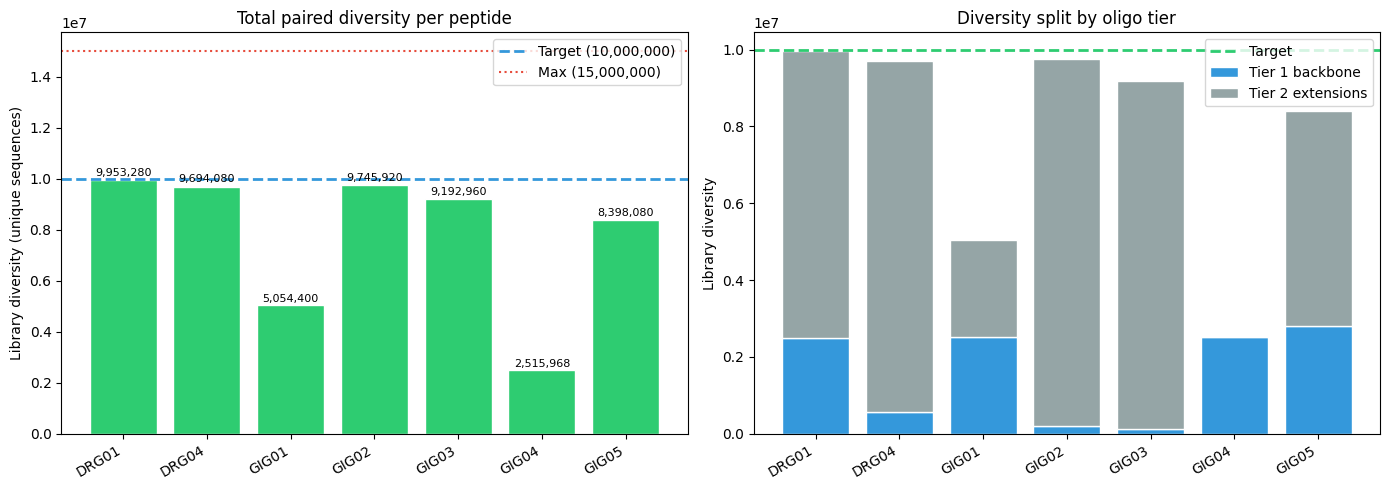

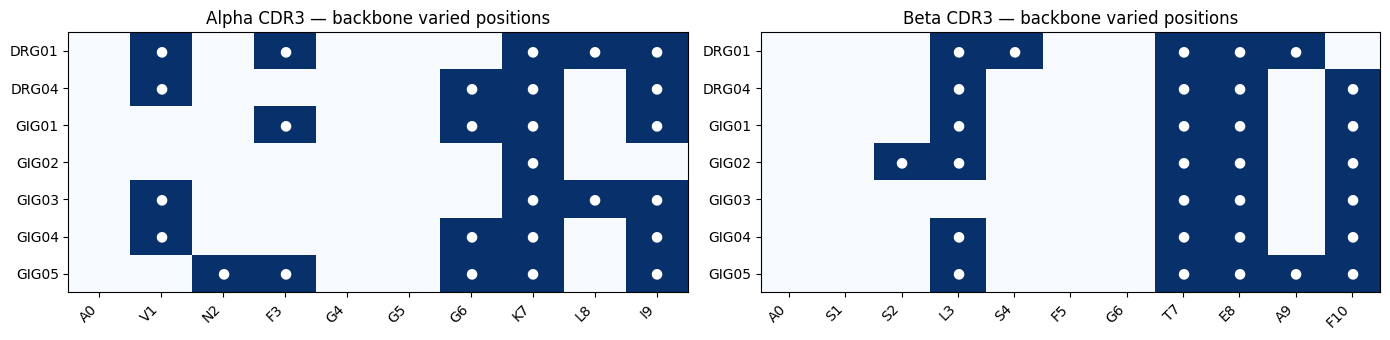

Codon efficiency (positions where IUPAC codon encodes unwanted AAs):
  DRG01: all codons at full efficiency
  DRG04_backbone: {"('alpha', 7)": 0.27}
  DRG04_ext_ap08: {"('alpha', 7)": 0.27}
  DRG04_ext_ap03: {"('alpha', 7)": 0.27}
  GIG01_backbone: {"('alpha', 7)": 0.23}
  GIG01_ext_bp02: {"('alpha', 7)": 0.23}
  GIG02_backbone: {"('beta', 7)": 0.2}
  GIG02_ext_ap00: {"('beta', 7)": 0.2}
  GIG02_ext_ap06: {"('beta', 7)": 0.2}
  GIG02_ext_ap09: {"('beta', 7)": 0.2}
  GIG02_ext_ap05: {"('beta', 7)": 0.2}
  GIG02_ext_ap03: {"('beta', 7)": 0.2}
  GIG02_ext_ap01: {"('beta', 7)": 0.2}
  GIG02_ext_ap04: {"('beta', 7)": 0.2}
  GIG03_ext_bp00: {"('beta', 0)": 0.2}
  GIG04_backbone: {"('alpha', 7)": 0.23}
  GIG05: all codons at full efficiency


In [61]:
# ── 1. Summary table ─────────────────────────────────────────────────────
rows = []
for pep in PEPTIDES:
    pool     = POOLS[pep]
    backbone = next((o for o in pool if o['oligo_type'] == 'tier1_backbone'), None)
    total_div = sum(o['unique_diversity'] for o in pool)
    a_var = sorted(backbone['alpha_varied_pos']) if backbone else []
    b_var = sorted(backbone['beta_varied_pos'])  if backbone else []
    all_effs = [e for o in pool for e in o['codon_efficiency'].values()]
    rows.append({
        'peptide':        pep,
        'n_oligos':       len(pool),
        'backbone_div':   backbone['diversity'] if backbone else 0,
        'total_div':      total_div,
        'pct_target':     round(100 * total_div / TARGET_DIVERSITY, 1),
        'n_alpha_var':    len(a_var),
        'n_beta_var':     len(b_var),
        'alpha_var_pos':  a_var,
        'beta_var_pos':   b_var,
        'mean_codon_eff': round(np.mean(all_effs), 3) if all_effs else 1.0,
        'n_leaky_oligos': sum(1 for o in pool if o.get('is_leaky', False)),
    })

summary_df = pd.DataFrame(rows)
display(summary_df[['peptide','n_oligos','backbone_div','total_div','pct_target',
                     'n_alpha_var','n_beta_var','mean_codon_eff','n_leaky_oligos']])

# ── 2. Total diversity vs target / max ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(PEPTIDES))

ax = axes[0]
colors = ['#e74c3c' if v > MAX_DIVERSITY else
          '#f39c12' if v > TARGET_DIVERSITY * 1.1 else '#2ecc71'
          for v in summary_df['total_div']]
bars = ax.bar(x, summary_df['total_div'], color=colors, edgecolor='white')
ax.axhline(TARGET_DIVERSITY, color='#3498db', lw=2,   ls='--', label=f'Target ({TARGET_DIVERSITY:,})')
ax.axhline(MAX_DIVERSITY,    color='#e74c3c', lw=1.5, ls=':',  label=f'Max ({MAX_DIVERSITY:,})')
ax.set_xticks(x); ax.set_xticklabels(PEPTIDES, rotation=30, ha='right')
ax.set_ylabel('Library diversity (unique sequences)')
ax.set_title('Total paired diversity per peptide')
ax.legend()
for bar, val in zip(bars, summary_df['total_div']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
            f'{val:,}', ha='center', va='bottom', fontsize=8)

# ── 3. Stacked bar: backbone vs extension contributions ───────────────────
ax2 = axes[1]
bb  = summary_df['backbone_div'].values
ext = summary_df['total_div'].values - bb
ax2.bar(x, bb,  label='Tier 1 backbone',    color='#3498db', edgecolor='white')
ax2.bar(x, ext, bottom=bb, label='Tier 2 extensions', color='#95a5a6', edgecolor='white')
ax2.axhline(TARGET_DIVERSITY, color='#2ecc71', lw=2, ls='--', label='Target')
ax2.set_xticks(x); ax2.set_xticklabels(PEPTIDES, rotation=30, ha='right')
ax2.set_ylabel('Library diversity')
ax2.set_title('Diversity split by oligo tier')
ax2.legend()

plt.tight_layout()
plt.show()

# ── 4. Backbone varied-position heatmap (alpha and beta) ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))
for chain, wt_seq, ax in [('alpha', WT_ALPHA, axes[0]), ('beta', WT_BETA, axes[1])]:
    n_pos = len(wt_seq)
    mat   = np.zeros((len(PEPTIDES), n_pos))
    for pi, pep in enumerate(PEPTIDES):
        bb = next((o for o in POOLS[pep] if o['oligo_type'] == 'tier1_backbone'), None)
        if bb:
            for p in bb[f'{chain}_varied_pos']:
                mat[pi, p] = 1
    ax.imshow(mat, cmap='Blues', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(n_pos))
    ax.set_xticklabels([f'{aa}{i}' for i, aa in enumerate(wt_seq)], rotation=45, ha='right')
    ax.set_yticks(range(len(PEPTIDES))); ax.set_yticklabels(PEPTIDES)
    ax.set_title(f'{chain.capitalize()} CDR3 — backbone varied positions')
    for pi in range(len(PEPTIDES)):
        for po in range(n_pos):
            if mat[pi, po]:
                ax.text(po, pi, '●', ha='center', va='center', fontsize=10, color='white')

plt.tight_layout()
plt.show()

# ── 5. Codon efficiency report ────────────────────────────────────────────
print('Codon efficiency (positions where IUPAC codon encodes unwanted AAs):')
any_leaky = False
for pep in PEPTIDES:
    leaky_oligos = [o for o in POOLS[pep] if o.get('is_leaky', False)]
    if leaky_oligos:
        any_leaky = True
        for o in leaky_oligos:
            bad = {str(k): round(v, 2) for k, v in o['codon_efficiency'].items()
                   if v < EFFICIENCY_THRESH}
            print(f'  {o["oligo_id"]}: {bad}')
    else:
        print(f'  {pep}: all codons at full efficiency')
if not any_leaky:
    print('  No leaky codons across any peptide.')


## Visualise: Paired Oligos

Each panel shows one oligo.  Alpha CDR3 positions (0–9) are on the left, beta CDR3 positions (0–10) on the right, separated by a dashed line.

- **■ grey square** = WT residue encoded at this position
- **● coloured circle** = non-WT amino acid encoded by the IUPAC codon
- **Shaded column** = variable position (more than one AA encoded)
- Colours indicate amino acid chemistry (hydrophobic / polar / basic / acidic)

The IUPAC triplet for each variable position is shown below the x-axis label.


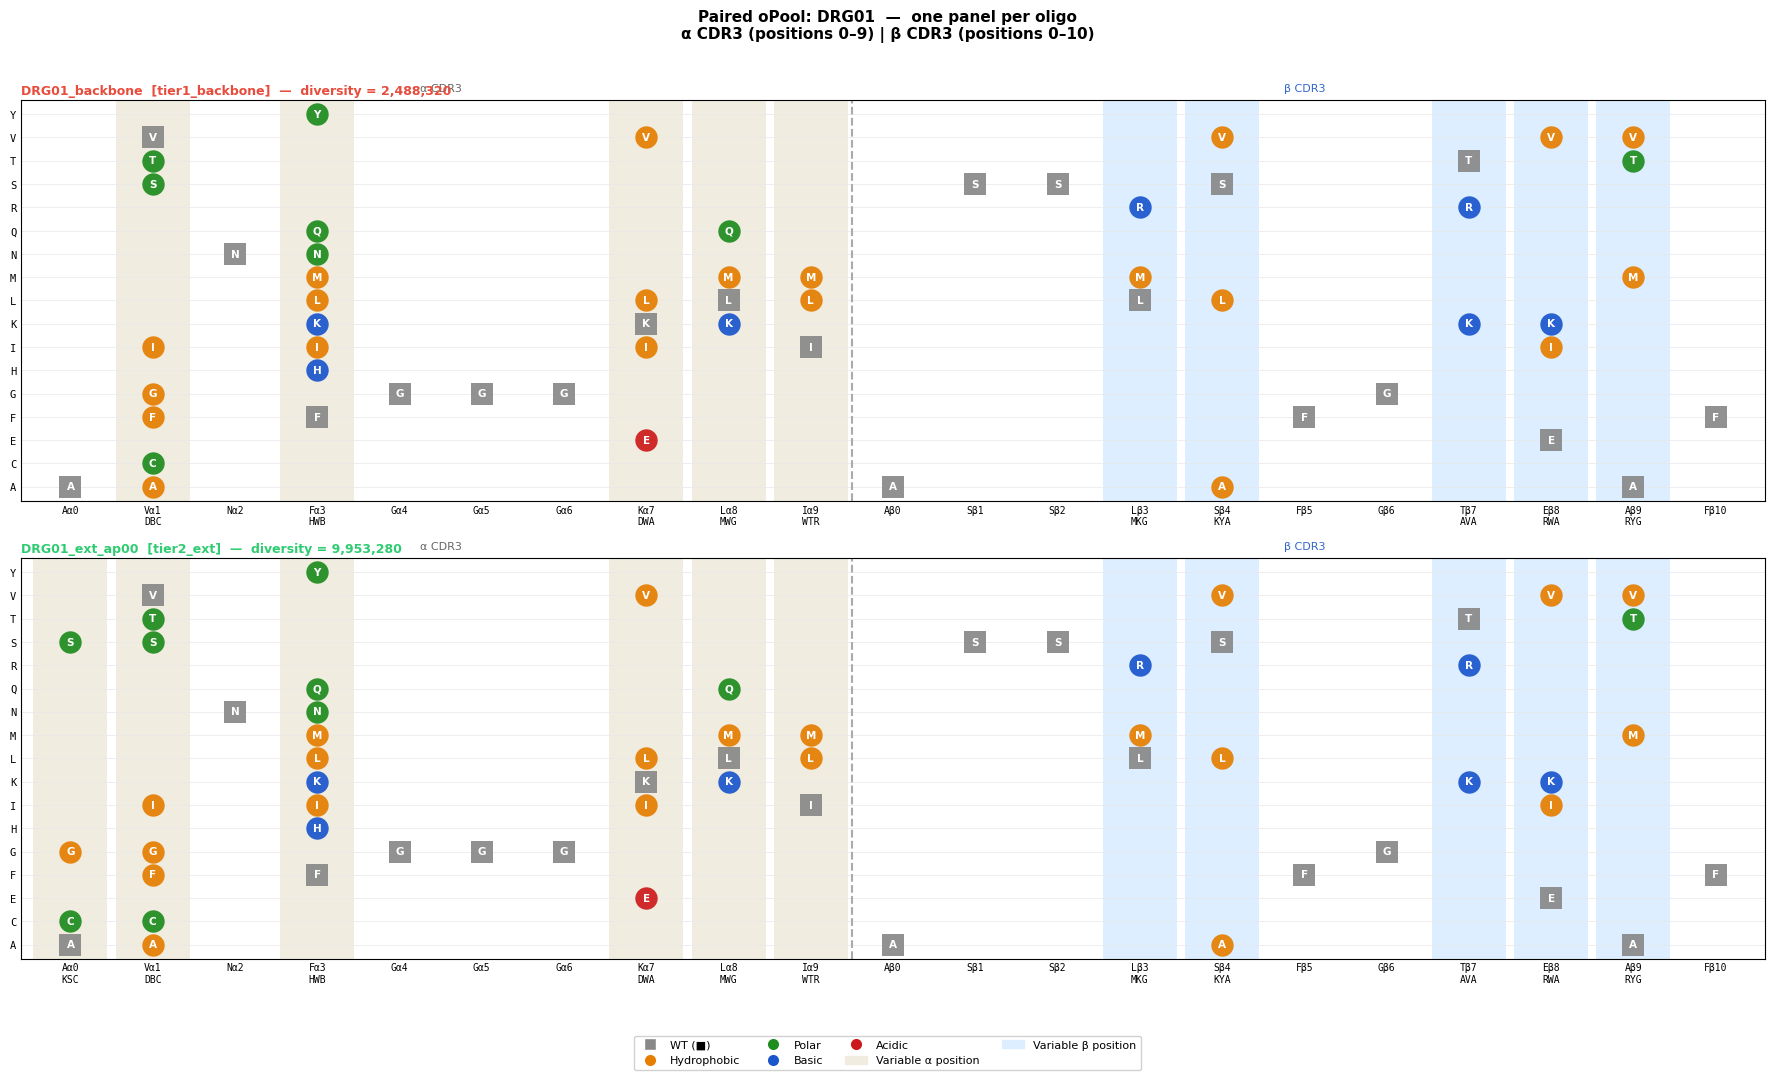

Saved → /cluster/home/sschulz/NGS_pipeline/notebooks/opool_designs_tcraft/opool_paired_DRG01_t0.33_tk2_per_oligo.pdf


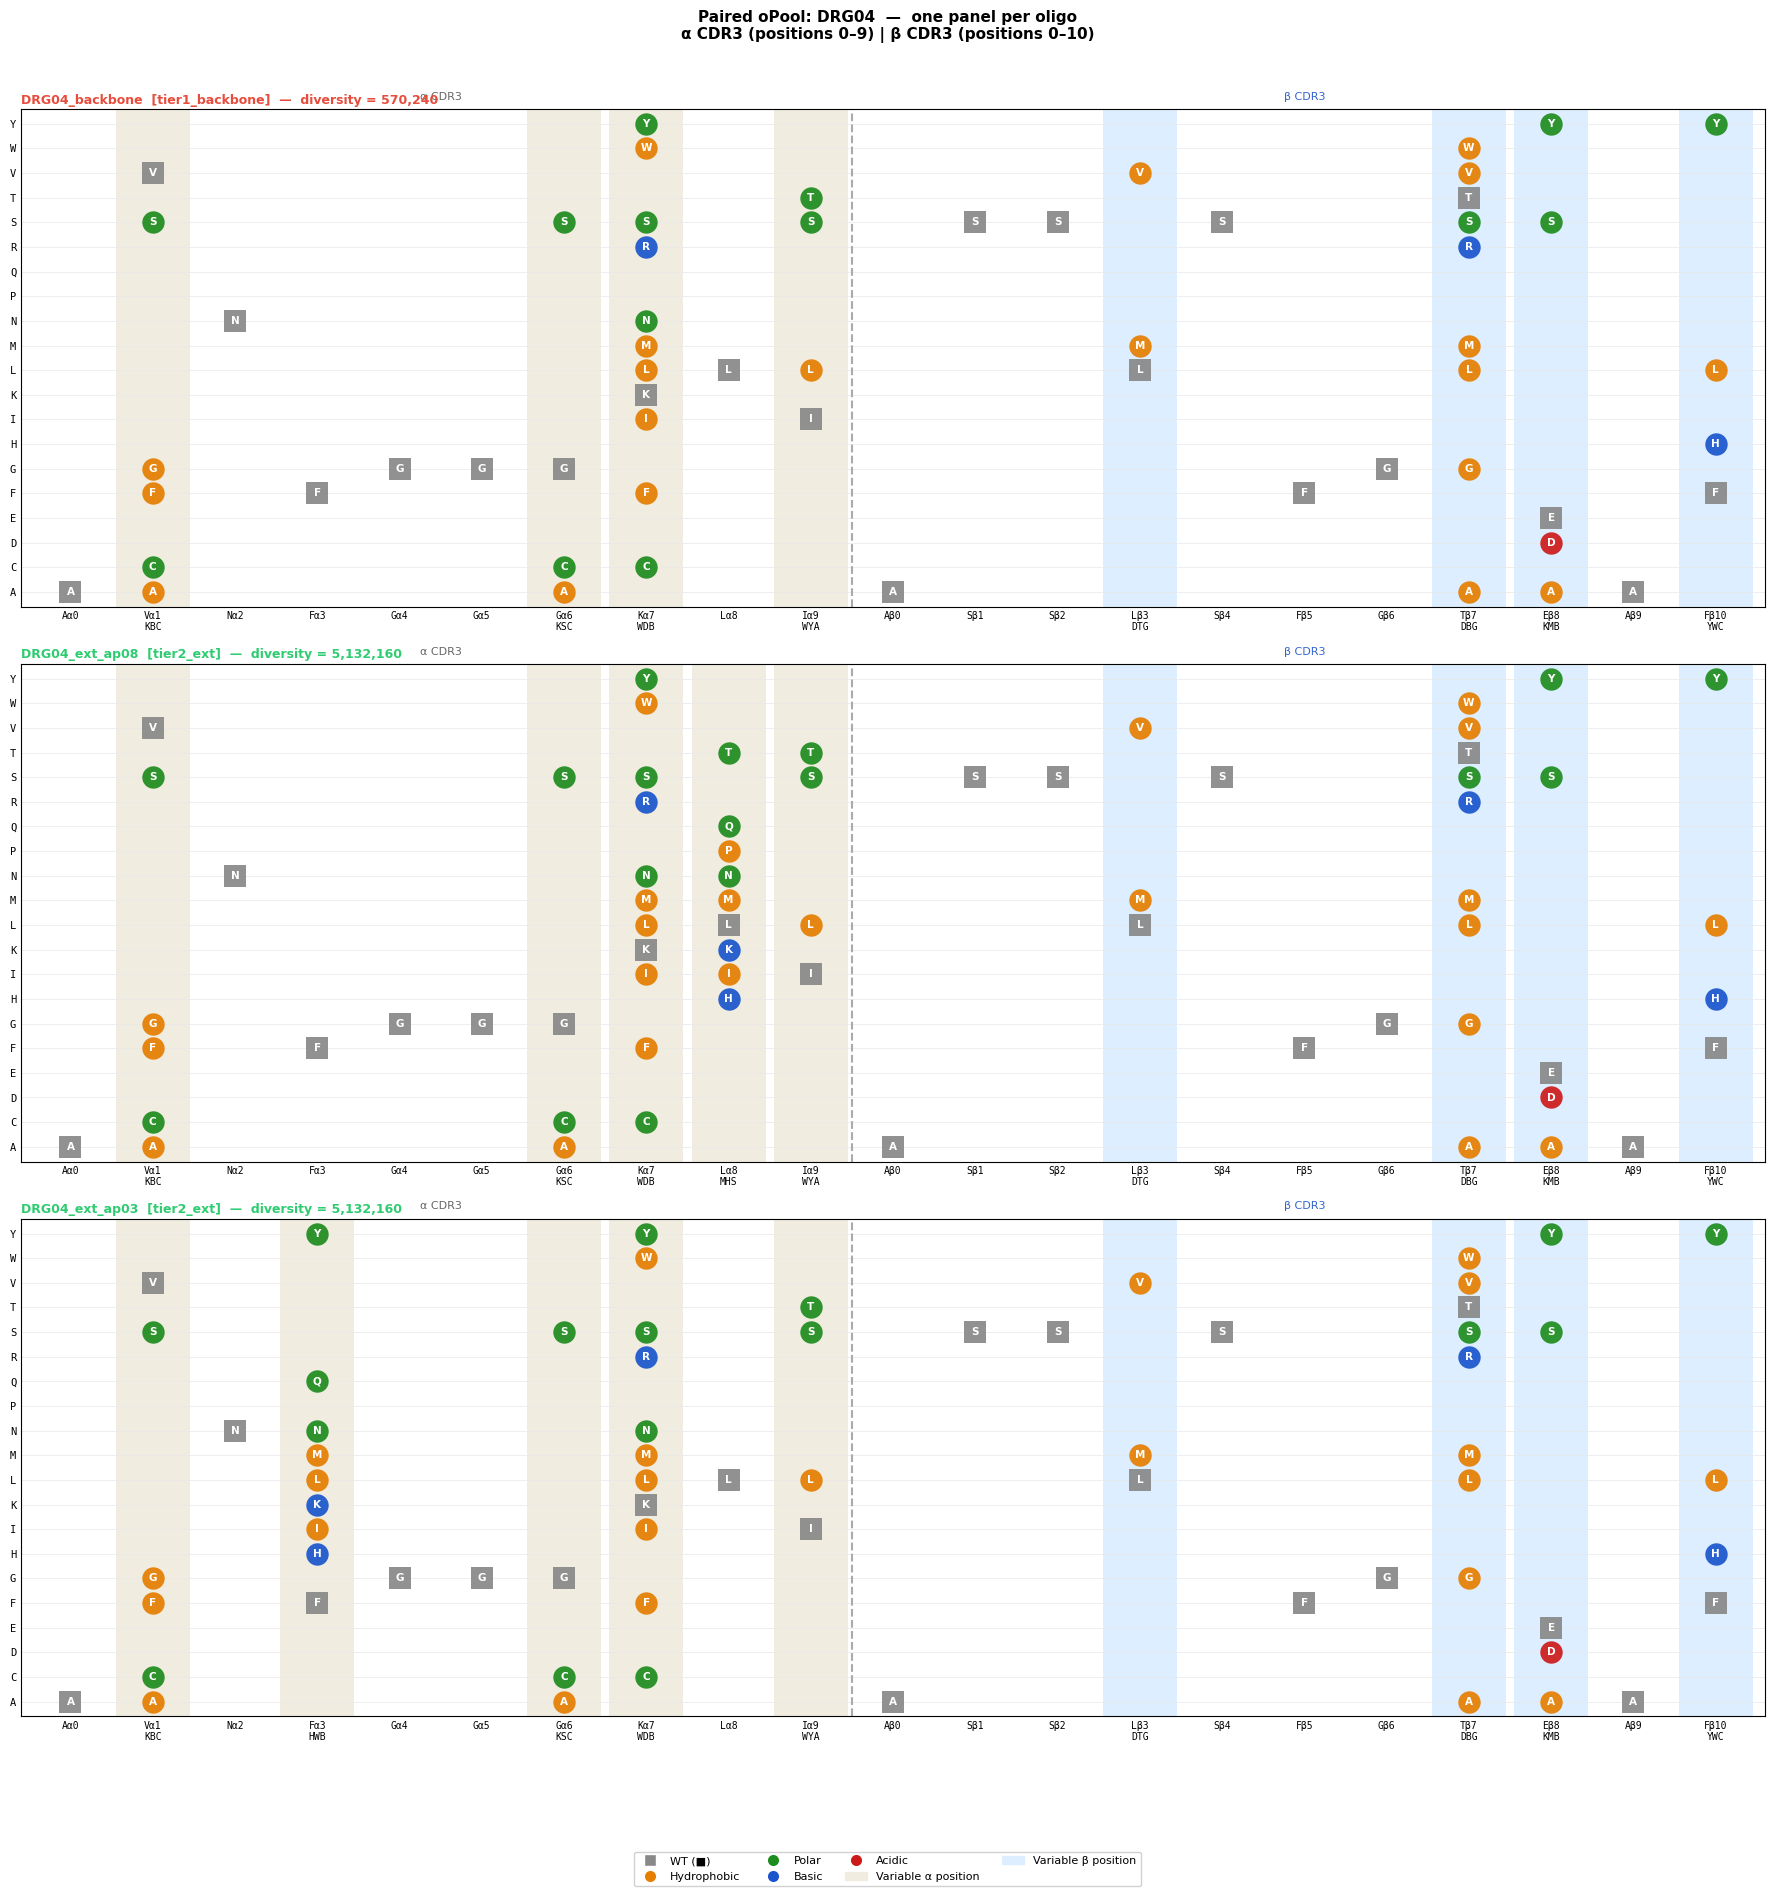

Saved → /cluster/home/sschulz/NGS_pipeline/notebooks/opool_designs_tcraft/opool_paired_DRG04_t0.33_tk2_per_oligo.pdf


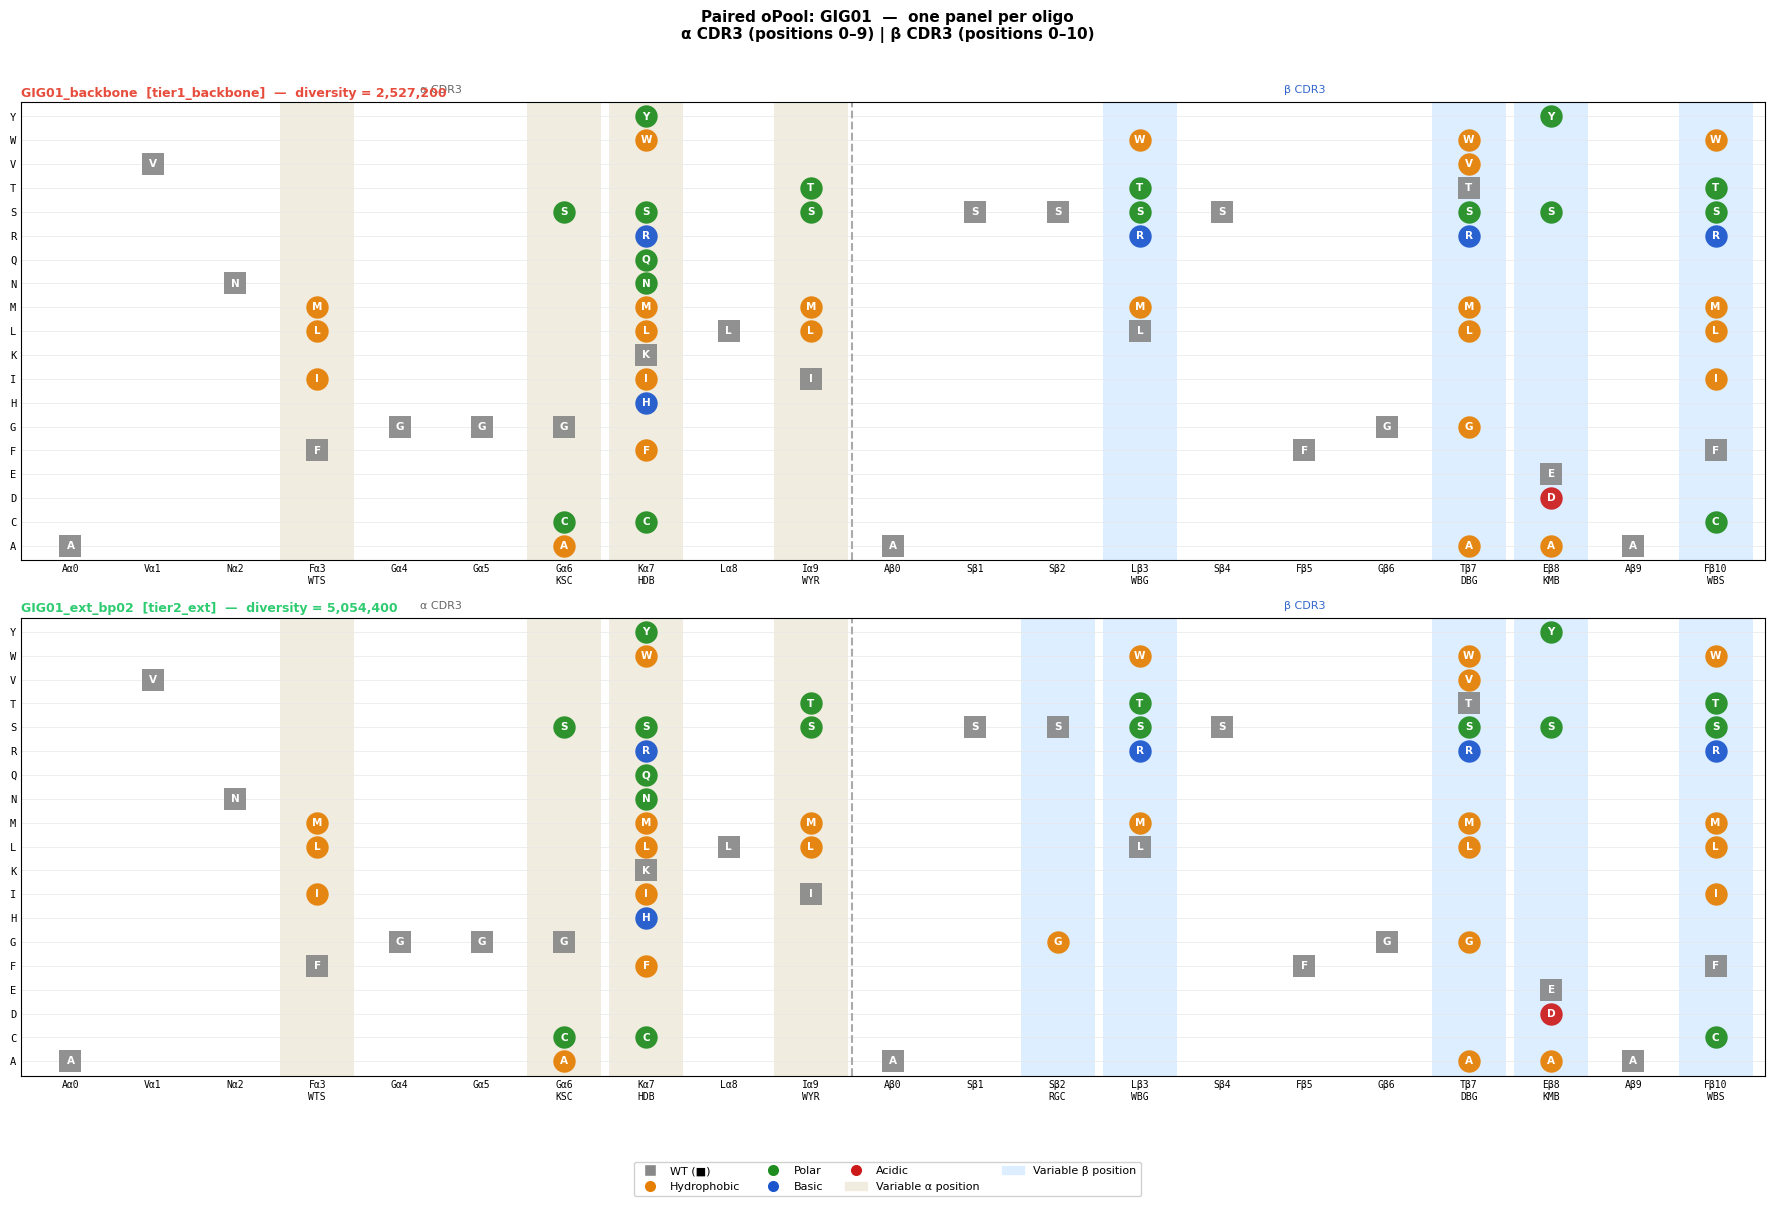

Saved → /cluster/home/sschulz/NGS_pipeline/notebooks/opool_designs_tcraft/opool_paired_GIG01_t0.33_tk2_per_oligo.pdf


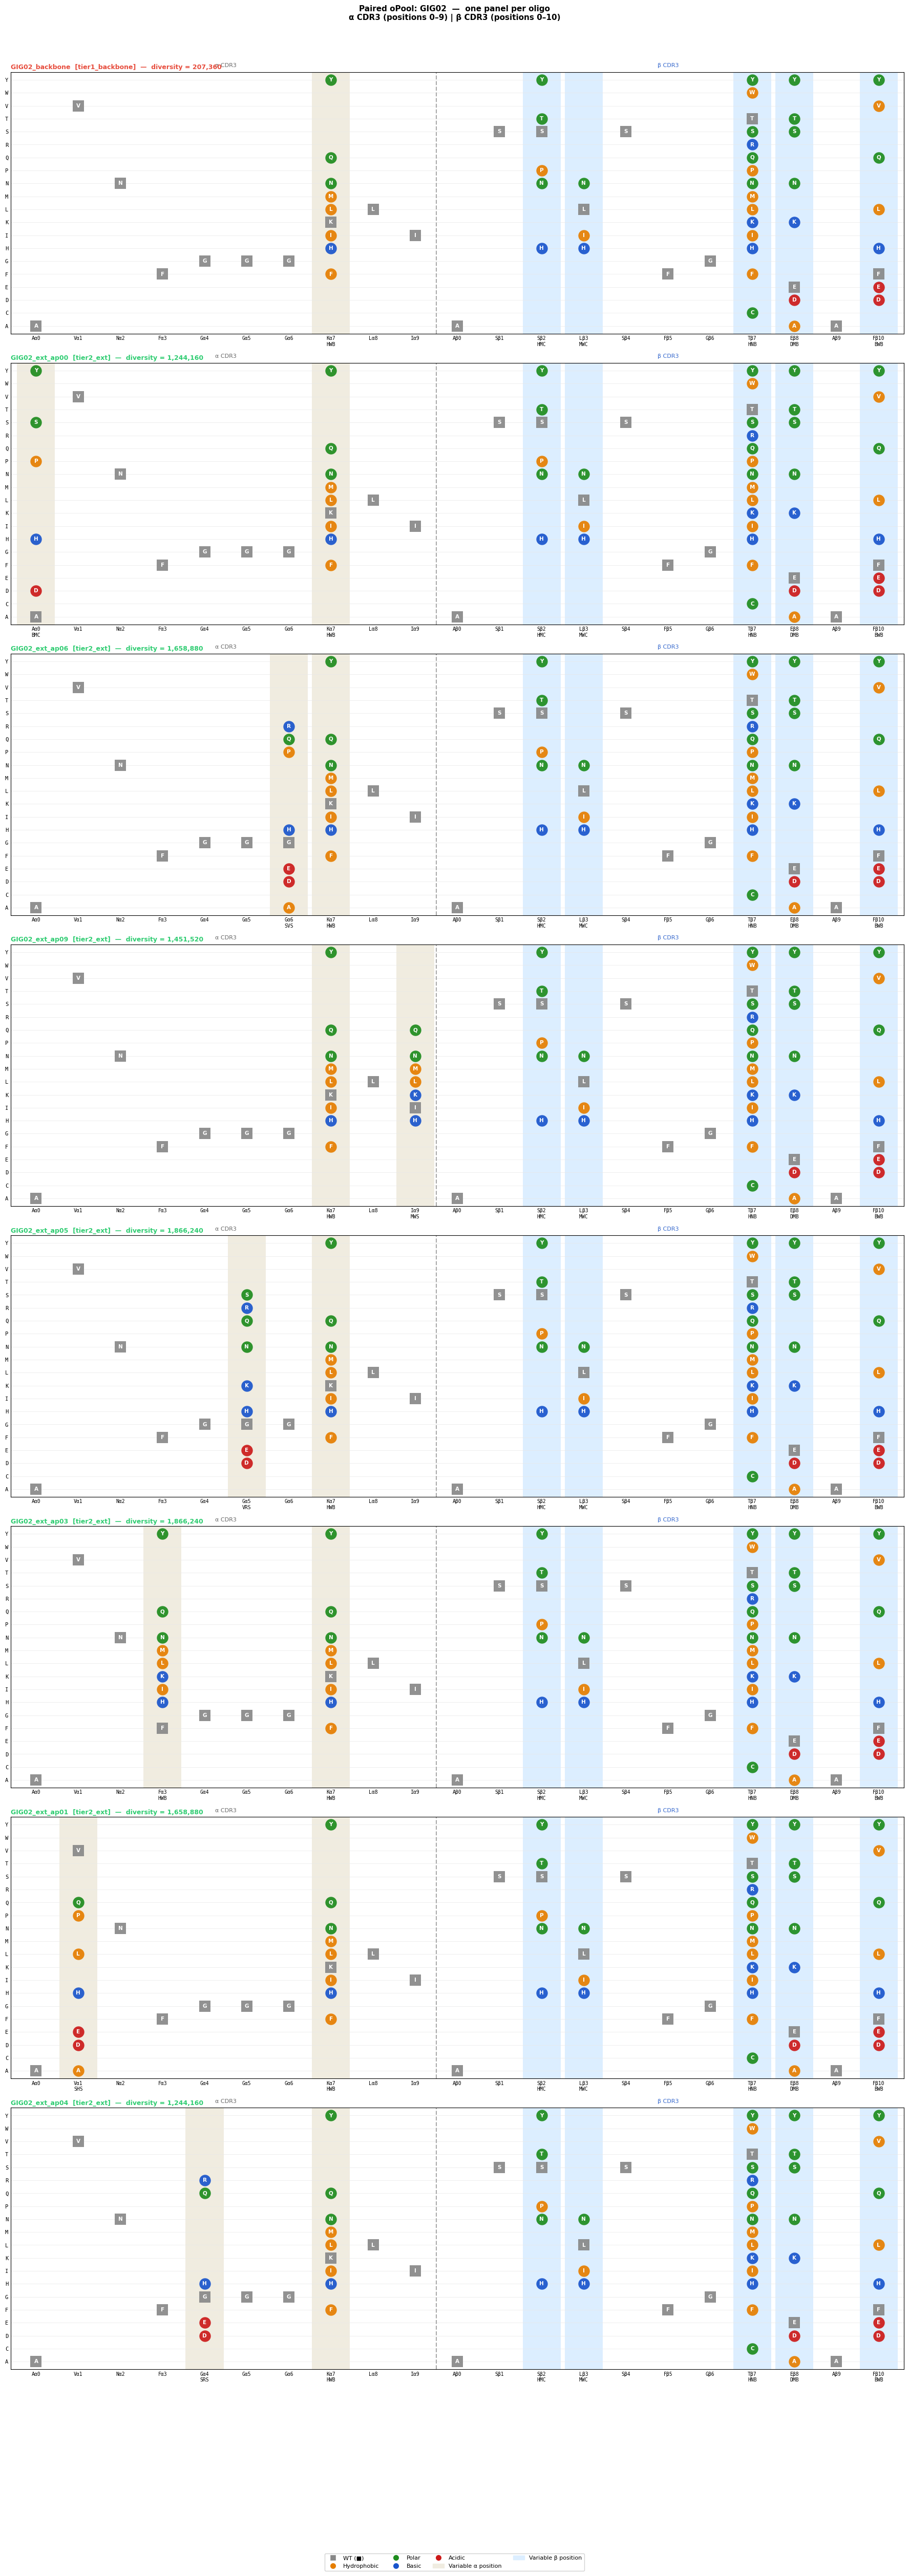

Saved → /cluster/home/sschulz/NGS_pipeline/notebooks/opool_designs_tcraft/opool_paired_GIG02_t0.33_tk2_per_oligo.pdf


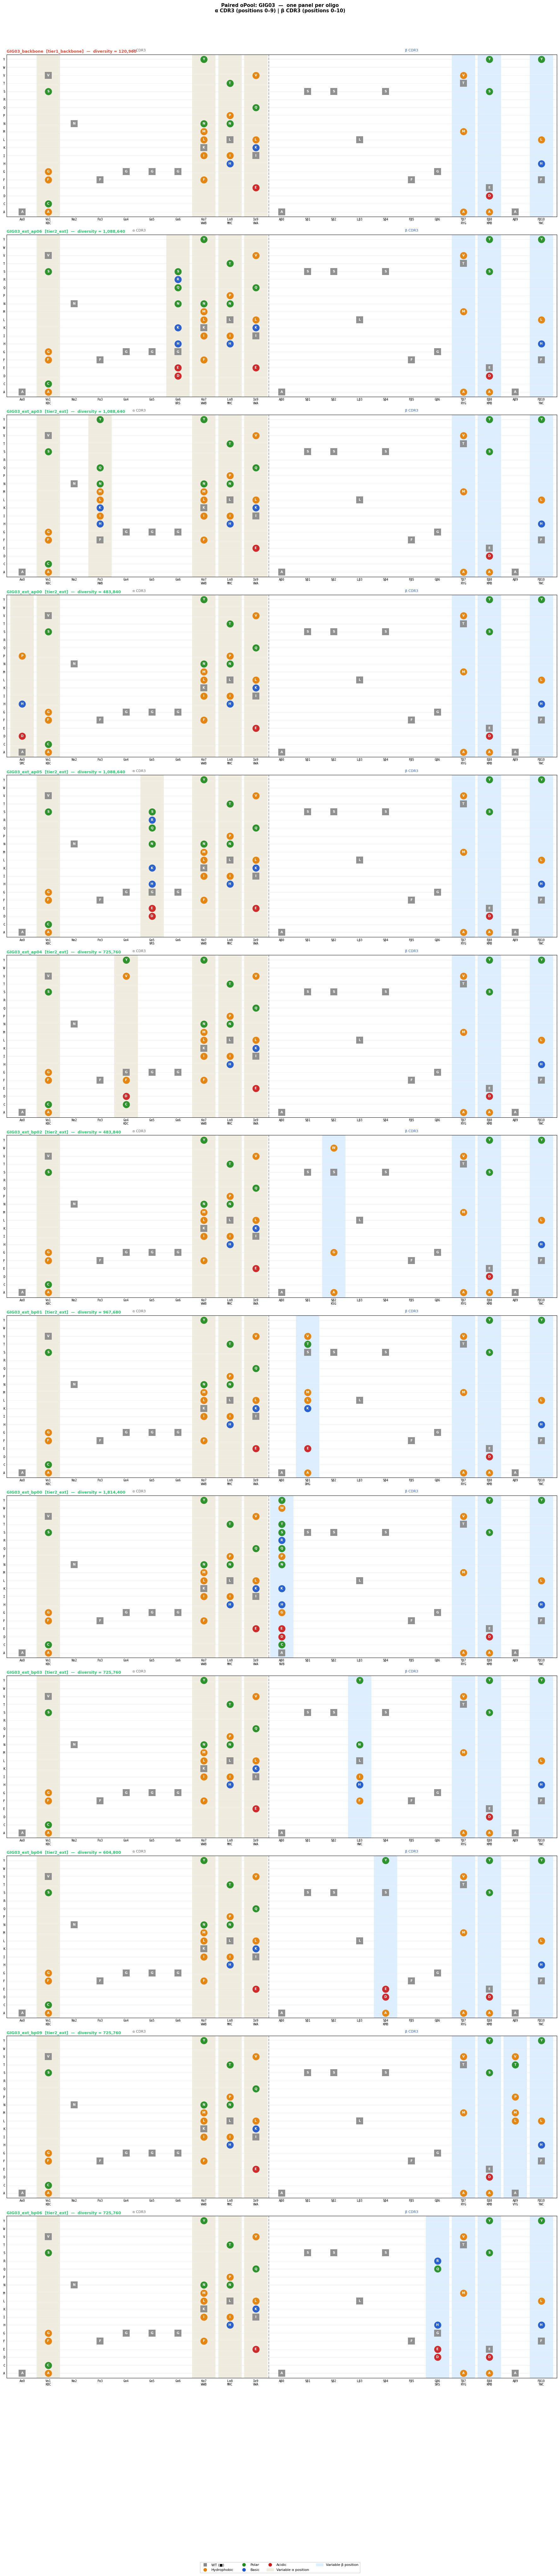

Saved → /cluster/home/sschulz/NGS_pipeline/notebooks/opool_designs_tcraft/opool_paired_GIG03_t0.33_tk2_per_oligo.pdf


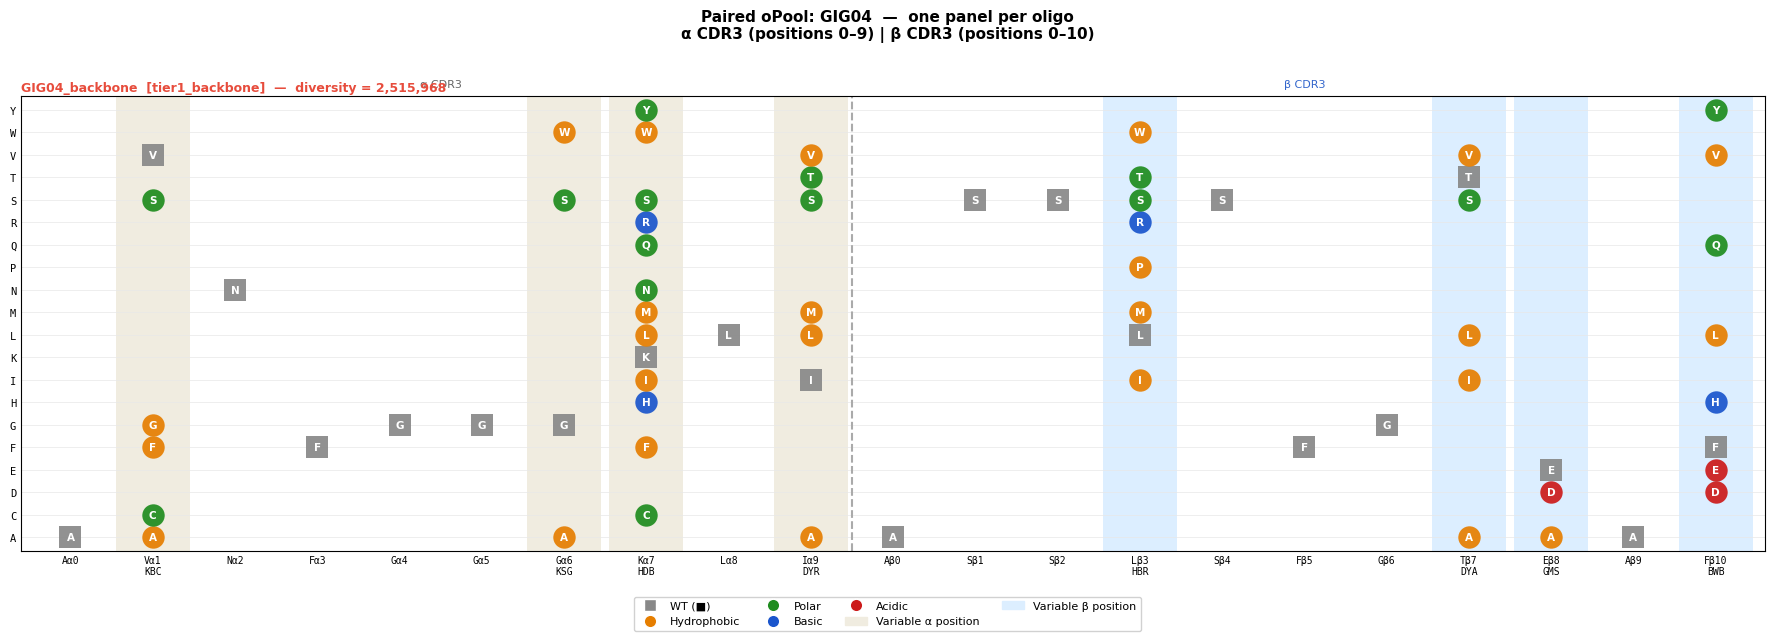

Saved → /cluster/home/sschulz/NGS_pipeline/notebooks/opool_designs_tcraft/opool_paired_GIG04_t0.33_tk2_per_oligo.pdf


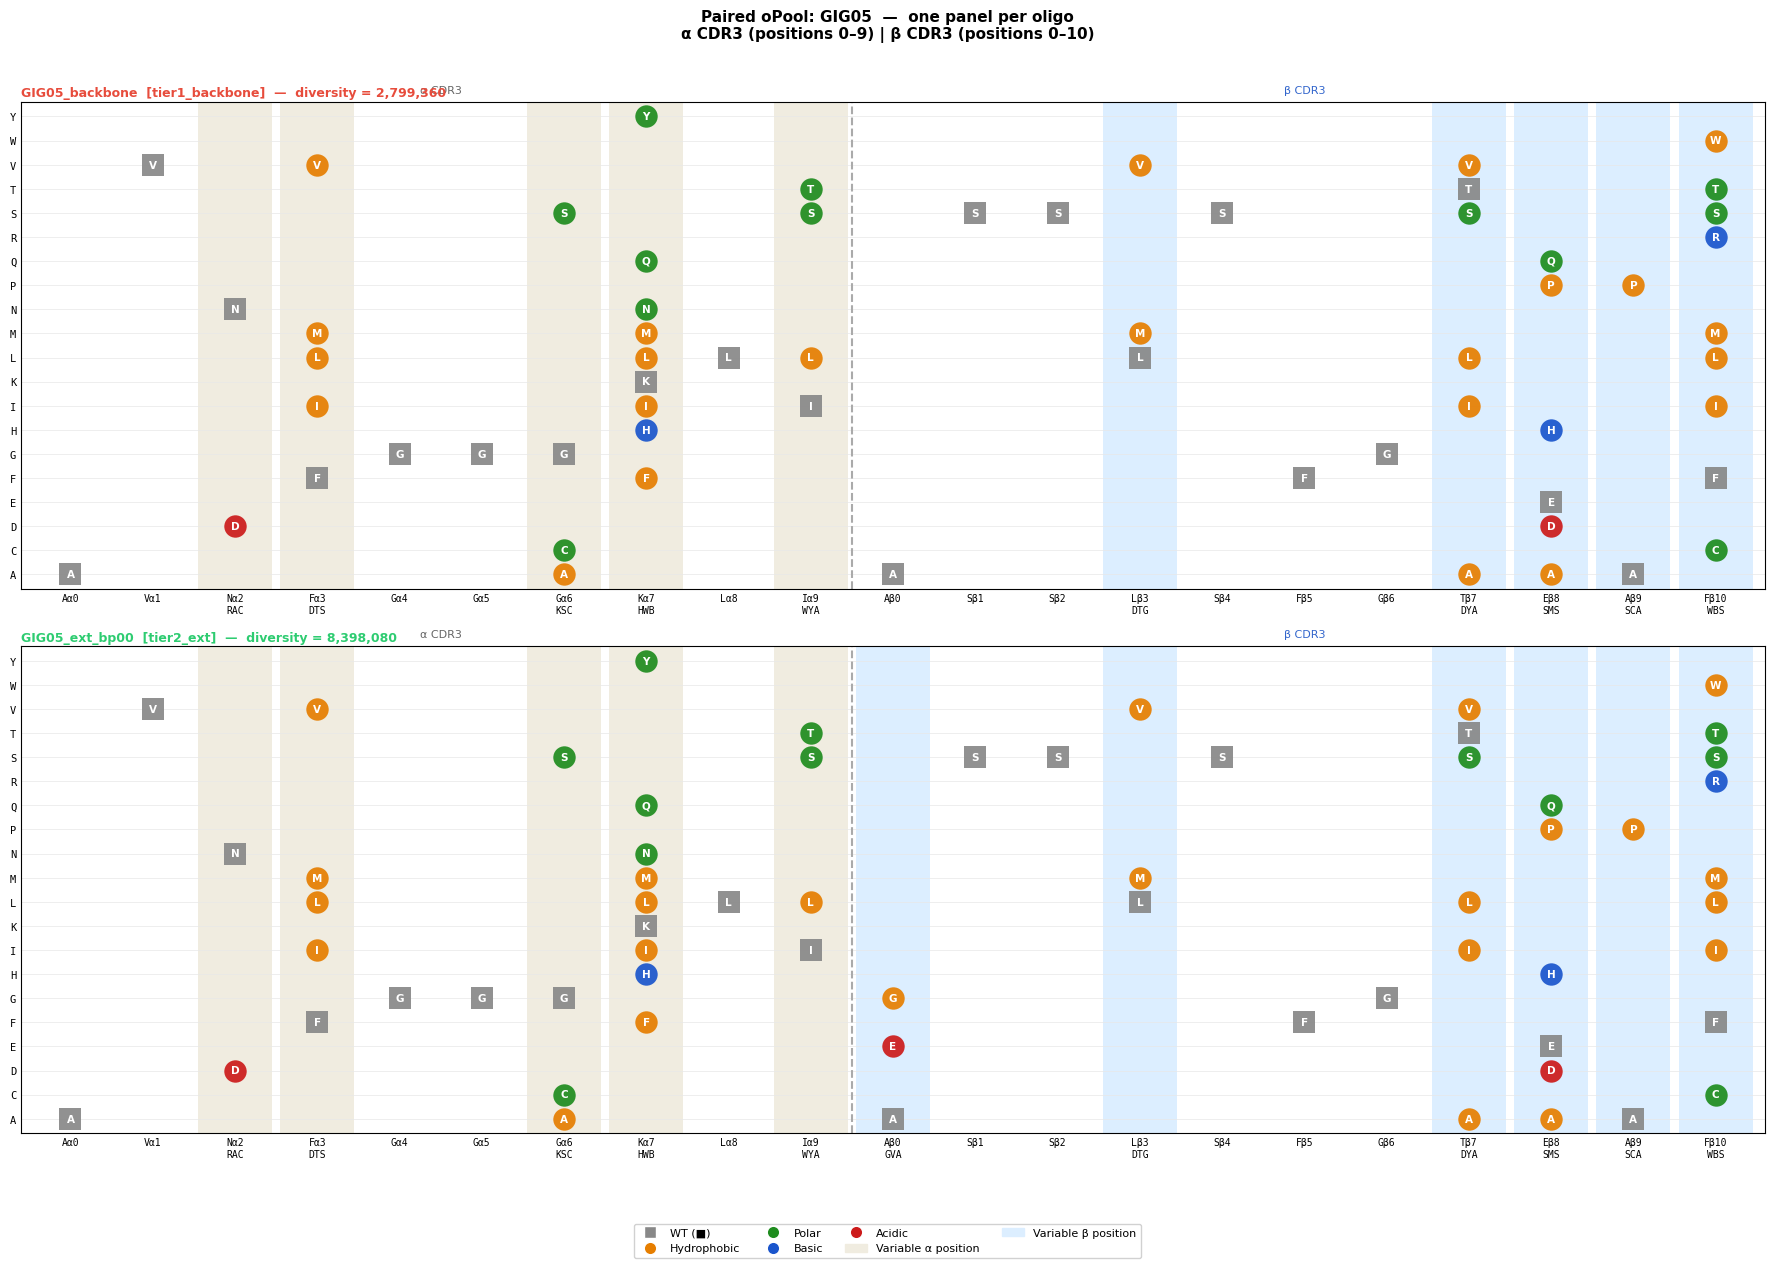

Saved → /cluster/home/sschulz/NGS_pipeline/notebooks/opool_designs_tcraft/opool_paired_GIG05_t0.33_tk2_per_oligo.pdf


In [62]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

AA_CHEM = {
    'A':'#e67e00','G':'#e67e00','V':'#e67e00','I':'#e67e00','L':'#e67e00',
    'M':'#e67e00','F':'#e67e00','W':'#e67e00','P':'#e67e00',
    'S':'#1e8c1e','T':'#1e8c1e','C':'#1e8c1e','Y':'#1e8c1e',
    'N':'#1e8c1e','Q':'#1e8c1e',
    'K':'#1a55cc','R':'#1a55cc','H':'#1a55cc',
    'D':'#cc1a1a','E':'#cc1a1a',
}
WT_COL = '#888888'
OLIGO_TYPE_COLOR = {'tier1_backbone': '#e74c3c', 'tier2_ext': '#2ecc71'}
SEP_X = ALPHA_LEN - 0.5   # vertical separator between alpha and beta sections


def plot_paired_pool(pep, pool):
    n_total = ALPHA_LEN + BETA_LEN   # 21 positions on x-axis

    all_aas = sorted({
        aa
        for o in pool
        for aas_dict in [o['alpha_position_aas'], o['beta_position_aas']]
        for aas in aas_dict.values()
        for aa in aas
    })
    aa_y   = {aa: i for i, aa in enumerate(all_aas)}
    n_aa   = len(all_aas)
    row_h  = max(3.0, n_aa * 0.32)

    n_oligos = len(pool)
    fig, axes = plt.subplots(n_oligos, 1,
                             figsize=(max(14, n_total * 0.85), row_h * n_oligos),
                             squeeze=False)

    for ax, oligo in zip(axes[:, 0], pool):
        # Shade variable positions
        for pos in range(ALPHA_LEN):
            if len(oligo['alpha_position_aas'][pos]) > 1:
                ax.axvspan(pos - 0.45, pos + 0.45, color='#f0ece0', zorder=0, lw=0)
        for pos in range(BETA_LEN):
            x = ALPHA_LEN + pos
            if len(oligo['beta_position_aas'][pos]) > 1:
                ax.axvspan(x - 0.45, x + 0.45, color='#dceeff', zorder=0, lw=0)

        # Chain separator
        ax.axvline(SEP_X, color='#aaaaaa', linewidth=1.5, linestyle='--', zorder=2)

        # Alpha positions
        for pos in range(ALPHA_LEN):
            wt_aa = WT_ALPHA[pos]
            for aa in sorted(oligo['alpha_position_aas'][pos]):
                color  = WT_COL if aa == wt_aa else AA_CHEM.get(aa, '#555555')
                marker = 's' if aa == wt_aa else 'o'
                ax.scatter(pos, aa_y[aa], s=260, color=color,
                           marker=marker, alpha=0.92, zorder=3, linewidths=0)
                ax.text(pos, aa_y[aa], aa, ha='center', va='center',
                        fontsize=7.5, fontweight='bold', color='white', zorder=4)

        # Beta positions
        for pos in range(BETA_LEN):
            x = ALPHA_LEN + pos
            wt_aa = WT_BETA[pos]
            for aa in sorted(oligo['beta_position_aas'][pos]):
                color  = WT_COL if aa == wt_aa else AA_CHEM.get(aa, '#555555')
                marker = 's' if aa == wt_aa else 'o'
                ax.scatter(x, aa_y[aa], s=260, color=color,
                           marker=marker, alpha=0.92, zorder=3, linewidths=0)
                ax.text(x, aa_y[aa], aa, ha='center', va='center',
                        fontsize=7.5, fontweight='bold', color='white', zorder=4)

        ax.set_xlim(-0.6, n_total - 0.4)
        ax.set_ylim(-0.6, n_aa - 0.4)
        ax.set_xticks(range(n_total))

        xlabels = []
        for i in range(ALPHA_LEN):
            base = f'{WT_ALPHA[i]}\u03b1{i}'
            if len(oligo['alpha_position_aas'][i]) > 1:
                xlabels.append(f'{base}\n{oligo["alpha_iupac"][i]}')
            else:
                xlabels.append(base)
        for i in range(BETA_LEN):
            base = f'{WT_BETA[i]}\u03b2{i}'
            if len(oligo['beta_position_aas'][i]) > 1:
                xlabels.append(f'{base}\n{oligo["beta_iupac"][i]}')
            else:
                xlabels.append(base)
        ax.set_xticklabels(xlabels, fontsize=7, fontfamily='monospace')

        ax.set_yticks(range(n_aa))
        ax.set_yticklabels(all_aas, fontsize=7.5, fontfamily='monospace')
        ax.tick_params(axis='x', length=0, pad=3)
        ax.tick_params(axis='y', length=0)
        ax.set_axisbelow(True)
        ax.yaxis.grid(True, color='#e8e8e8', linewidth=0.5)

        # Chain labels
        ax.text(ALPHA_LEN / 2 - 0.5, n_aa - 0.1, '\u03b1 CDR3',
                ha='center', va='bottom', fontsize=8, color='#666666')
        ax.text(ALPHA_LEN + BETA_LEN / 2 - 0.5, n_aa - 0.1, '\u03b2 CDR3',
                ha='center', va='bottom', fontsize=8, color='#3366cc')

        otype = oligo['oligo_type']
        tc    = OLIGO_TYPE_COLOR.get(otype, '#555')
        ax.set_title(
            f"{oligo['oligo_id']}  [{otype}]  —  diversity = {oligo['diversity']:,}",
            fontsize=9, loc='left', pad=4, color=tc, fontweight='bold',
        )

    legend_handles = [
        mlines.Line2D([], [], marker='s', color='w', markerfacecolor=WT_COL, markersize=9, label='WT (\u25a0)'),
        mlines.Line2D([], [], marker='o', color='w', markerfacecolor='#e67e00', markersize=9, label='Hydrophobic'),
        mlines.Line2D([], [], marker='o', color='w', markerfacecolor='#1e8c1e', markersize=9, label='Polar'),
        mlines.Line2D([], [], marker='o', color='w', markerfacecolor='#1a55cc', markersize=9, label='Basic'),
        mlines.Line2D([], [], marker='o', color='w', markerfacecolor='#cc1a1a', markersize=9, label='Acidic'),
        mpatches.Patch(color='#f0ece0', label='Variable \u03b1 position'),
        mpatches.Patch(color='#dceeff', label='Variable \u03b2 position'),
    ]
    fig.legend(handles=legend_handles, loc='lower center', ncol=4,
               fontsize=8, bbox_to_anchor=(0.5, 0.0), framealpha=0.9)
    fig.suptitle(f'Paired oPool: {pep}  —  one panel per oligo\n'
                 f'\u03b1 CDR3 (positions 0\u20139) | \u03b2 CDR3 (positions 0\u201310)',
                 fontsize=11, fontweight='bold')
    plt.tight_layout(rect=[0, 0.07, 1, 0.97])

    pdf = OUT_DIR / f'opool_paired_{pep}_t{TIER1_FRAC}_tk{TOP_K}_per_oligo.pdf'
    png = OUT_DIR / f'opool_paired_{pep}_t{TIER1_FRAC}_tk{TOP_K}_per_oligo.png'
    plt.savefig(pdf, bbox_inches='tight')
    plt.savefig(png, bbox_inches='tight', dpi=150)
    plt.show()
    print(f'Saved \u2192 {pdf}')


for pep in PEPTIDES:
    plot_paired_pool(pep, POOLS[pep])

## Export to CSV

One CSV per peptide containing all oligos (backbone + extensions).  Columns include the IUPAC DNA sequences, varied positions, per-oligo diversity, and codon efficiency.

The `paired_dna` column is `alpha_dna + beta_dna` with **no adapters** — add those externally once the TCRAFT cloning adapters are finalised.

An IDT-format order sheet (`IDT_opool_paired_order.csv`) is also written with one row per oligo across all peptides.


In [10]:
def pool_to_df(pep, pool):
    rows, cumul = [], 0
    for o in pool:
        cumul += o['unique_diversity']
        alpha_var = '; '.join(
            f'p{p}:[{",".join(sorted(o["alpha_position_aas"][p]))}]'
            for p in o['alpha_varied_pos']
        )
        beta_var = '; '.join(
            f'p{p}:[{",".join(sorted(o["beta_position_aas"][p]))}]'
            for p in o['beta_varied_pos']
        )
        effs = [e for e in o['codon_efficiency'].values() if e < 1.0]
        rows.append({
            'oligo_id':               o['oligo_id'],
            'oligo_type':             o['oligo_type'],
            'alpha_dna':              o['alpha_dna'],
            'beta_dna':               o['beta_dna'],
            'paired_dna':             o['paired_dna'],
            'paired_dna_length_nt':   len(o['paired_dna']),
            'n_alpha_varied':         o['n_alpha_varied'],
            'n_beta_varied':          o['n_beta_varied'],
            'alpha_varied_positions': alpha_var,
            'beta_varied_positions':  beta_var,
            'diversity':              o['diversity'],
            'unique_diversity':       o['unique_diversity'],
            'cumulative_diversity':   cumul,
            'mean_codon_efficiency':  round(np.mean(effs), 3) if effs else 1.0,
            'is_leaky':               o.get('is_leaky', False),
        })
    return pd.DataFrame(rows)


idt_rows = []
for pep, pool in POOLS.items():
    df   = pool_to_df(pep, pool)
    path = OUT_DIR / f'opool_paired_{pep}.csv'
    df.to_csv(path, index=False)
    print(f'Wrote {path}  ({len(df)} oligos)')
    display(df[['oligo_id','oligo_type','alpha_dna','beta_dna',
                'n_alpha_varied','n_beta_varied','diversity','unique_diversity']])
    order = df[['oligo_id', 'paired_dna']].copy()
    order.insert(0, 'Pool Name', pep)
    idt_rows.append(order)

idt_df   = pd.concat(idt_rows, ignore_index=True)
idt_df   = idt_df.rename(columns={'oligo_id': 'Sequence Name', 'paired_dna': 'Sequence (no adapters)'})
idt_path = OUT_DIR / 'IDT_opool_paired_order.csv'
idt_df.to_csv(idt_path, index=False)
print(f'\nIDT order sheet (adapters TBD) → {idt_path}  ({len(idt_df)} oligos total)')
display(idt_df)

Wrote /cluster/project/reddy/marluca/NGS_pipeline/notebooks/opool_designs_tcraft/opool_paired_DRG01.csv  (4 oligos)


,oligo_id,oligo_type,alpha_dna,beta_dna,n_alpha_varied,n_beta_varied,diversity,unique_diversity
0,DRG01_backbone,tier1_backbone,GCAGYAAACWTSGGAGGAGGADWGWTGWTR,GCAAGCYCAMKGKYATTCGGAAVARWARCABNH,5,7,1935360,1935360
1,DRG01_ext_ap00,tier2_ext,GSAGYAAACWTSGGAGGAGGADWGWTGWTR,GCAAGCYCAMKGKYATTCGGAAVARWARCABNH,6,7,3870720,1935360
2,DRG01_ext_bp01,tier2_ext,GCAGYAAACWTSGGAGGAGGADWGWTGWTR,GCATMCYCAMKGKYATTCGGAAVARWARCABNH,5,8,3870720,1935360
3,DRG01_ext_ap02,tier2_ext,GCAGYAMACWTSGGAGGAGGADWGWTGWTR,GCAAGCYCAMKGKYATTCGGAAVARWARCABNH,6,7,3870720,1935360


Wrote /cluster/project/reddy/marluca/NGS_pipeline/notebooks/opool_designs_tcraft/opool_paired_DRG04.csv  (2 oligos)


,oligo_id,oligo_type,alpha_dna,beta_dna,n_alpha_varied,n_beta_varied,diversity,unique_diversity
0,DRG04_backbone,tier1_backbone,GCAGYAAACWTSGGAGGARGCWDGWYGDYR,GCAAGCRGCDTRKCATTCGGARYGBMAGCAYWC,6,6,2867200,2867200
1,DRG04_ext_ap00,tier2_ext,GVCGYAAACWTSGGAGGARGCWDGWYGDYR,GCAAGCRGCDTRKCATTCGGARYGBMAGCAYWC,7,6,8601600,5734400


Wrote /cluster/project/reddy/marluca/NGS_pipeline/notebooks/opool_designs_tcraft/opool_paired_GIG01.csv  (2 oligos)


...

,oligo_id,oligo_type,alpha_dna,beta_dna,n_alpha_varied,n_beta_varied,diversity,unique_diversity
0,GIG04_backbone,tier1_backbone,GCAGYAAACTTCGGAGGARGCWDBWYGDYA,GCAAGCRGCWYAKCATTCGGARBCKMBGCAHWC,5,6,3041280,3041280
1,GIG04_ext_ap03,tier2_ext,GCAGYAAACTWCGGAGGARGCWDBWYGDYA,GCAAGCRGCWYAKCATTCGGARBCKMBGCAHWC,6,6,6082560,3041280
2,GIG04_ext_bp09,tier2_ext,GCAGYAAACTTCGGAGGARGCWDBWYGDYA,GCAAGCRGCWYAKCATTCGGARBCKMBGSAHWC,5,7,6082560,3041280


Wrote /cluster/project/reddy/marluca/NGS_pipeline/notebooks/opool_designs_tcraft/opool_paired_GIG05.csv  (3 oligos)


,oligo_id,oligo_type,alpha_dna,beta_dna,n_alpha_varied,n_beta_varied,diversity,unique_diversity
0,GIG05_backbone,tier1_backbone,GCARTARACDTSGGAGGARSCWDGCTAWYR,GCAAGCRGCDTGAVCTTCGGAABCGMASCAYWC,6,7,1728000,1728000
1,GIG05_ext_ap00,tier2_ext,GVCRTARACDTSGGAGGARSCWDGCTAWYR,GCAAGCRGCDTGAVCTTCGGAABCGMASCAYWC,7,7,5184000,3456000
2,GIG05_ext_bp00,tier2_ext,GCARTARACDTSGGAGGARSCWDGCTAWYR,GVAAGCRGCDTGAVCTTCGGAABCGMASCAYWC,6,8,5184000,3456000



IDT order sheet (adapters TBD) → /cluster/project/reddy/marluca/NGS_pipeline/notebooks/opool_designs_tcraft/IDT_opool_paired_order.csv  (19 oligos total)


,Pool Name,Sequence Name,Sequence (no adapters)
0,DRG01,DRG01_backbone,GCAGYAAACWTSGGAGGAGGADWGWTGWTRGCAAGCYCAMKGKYAT...
1,DRG01,DRG01_ext_ap00,GSAGYAAACWTSGGAGGAGGADWGWTGWTRGCAAGCYCAMKGKYAT...
2,DRG01,DRG01_ext_bp01,GCAGYAAACWTSGGAGGAGGADWGWTGWTRGCATMCYCAMKGKYAT...
3,DRG01,DRG01_ext_ap02,GCAGYAMACWTSGGAGGAGGADWGWTGWTRGCAAGCYCAMKGKYAT...
4,DRG04,DRG04_backbone,GCAGYAAACWTSGGAGGARGCWDGWYGDYRGCAAGCRGCDTRKCAT...
5,DRG04,DRG04_ext_ap00,GVCGYAAACWTSGGAGGARGCWDGWYGDYRGCAAGCRGCDTRKCAT...
6,GIG01,GIG01_backbone,GCAGYAAACWTSGGAGGAGSAWDGWYGWYAGCAAGCAGCDTRKCAT...
7,GIG01,GIG01_ext_bp02,GCAGYAAACWTSGGAGGAGSAWDGWYGWYAGCAAGCDGCDTRKCAT...
8,GIG02,GIG02_backbone,GCAGTAAACWTCGRCGRAGRAAWGCTAAWAGCAAGCADCCWCYMCW...
9,GIG02,GIG02_ext_bp01,GCAGTAAACWTCGRCGRAGRAAWGCTAAWAGCAARCADCCWCYMCW...
